# Street-View Coverage Tile Acquisition Notebook

This notebook collects and visualizes street-view coverage tiles from multiple webpage-facing sources.

The sections follow a consistent pattern where possible:

1. configure the source, area of interest, and zoom level
2. build source tile jobs from the requested bounding box
3. fetch tiles and write manifests / per-tile summaries
4. visualize raw tiles, decoded features, or coverage masks against a map context

Unless noted otherwise, tile ranges use the standard XYZ Web Mercator grid. Yandex is the exception: its street-view raster tiles are requested and visualized with Yandex's WGS84 elliptic Mercator tile grid.


## Shared Setup

Common imports and helper functions used by the remaining raster and vector tile workflows.


In [100]:
from __future__ import annotations

import csv
import gzip
import hashlib
import io
import json
import math
import re
import os
import shutil
import subprocess
import tempfile
from datetime import datetime, timezone
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.parse import urlparse
from urllib.request import Request, urlopen
from typing import Any

import numpy as np
import requests

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Rectangle
from IPython.display import Image, display


In [101]:
def utc_now_iso() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()


def ensure_directory(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def sha256_bytes(payload: bytes) -> str:
    return hashlib.sha256(payload).hexdigest()


def lonlat_to_tile(lon: float, lat: float, zoom: int) -> tuple[int, int]:
    lat_rad = math.radians(lat)
    n = 2 ** zoom
    x = int((lon + 180.0) / 360.0 * n)
    y = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return x, y


def bbox_to_tile_range(bbox: dict[str, float], zoom: int) -> dict[str, int]:
    x1, y2 = lonlat_to_tile(bbox['min_lon'], bbox['min_lat'], zoom)
    x2, y1 = lonlat_to_tile(bbox['max_lon'], bbox['max_lat'], zoom)
    return {
        'x_min': min(x1, x2),
        'x_max': max(x1, x2),
        'y_min': min(y1, y2),
        'y_max': max(y1, y2),
    }


def tile_count(tile_range: dict[str, int]) -> int:
    return (tile_range['x_max'] - tile_range['x_min'] + 1) * (tile_range['y_max'] - tile_range['y_min'] + 1)


def split_bbox_into_grid(bbox: dict[str, float], rows: int, cols: int) -> list[dict]:
    lon_step = (bbox['max_lon'] - bbox['min_lon']) / cols
    lat_step = (bbox['max_lat'] - bbox['min_lat']) / rows
    subboxes = []
    index = 0
    for row in range(rows):
        for col in range(cols):
            subboxes.append({
                'index': index,
                'row': row,
                'col': col,
                'bbox': {
                    'min_lon': bbox['min_lon'] + col * lon_step,
                    'max_lon': bbox['min_lon'] + (col + 1) * lon_step,
                    'min_lat': bbox['min_lat'] + row * lat_step,
                    'max_lat': bbox['min_lat'] + (row + 1) * lat_step,
                },
            })
            index += 1
    return subboxes


def select_subboxes(subboxes: list[dict], selector) -> list[dict]:
    if selector is None:
        return subboxes
    if isinstance(selector, int):
        selector = [selector]
    wanted = set(selector)
    return [subbox for subbox in subboxes if subbox['index'] in wanted]


def iter_tile_coords(tile_range: dict[str, int]):
    for x in range(tile_range['x_min'], tile_range['x_max'] + 1):
        for y in range(tile_range['y_min'], tile_range['y_max'] + 1):
            yield x, y


def tile_to_lonlat_bounds(x: int, y: int, zoom: int) -> tuple[float, float, float, float]:
    n = 2 ** zoom
    lon_min = x / n * 360.0 - 180.0
    lon_max = (x + 1) / n * 360.0 - 180.0
    lat_max = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n))))
    lat_min = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * (y + 1) / n))))
    return lon_min, lat_min, lon_max, lat_max


def write_csv(path: Path, rows: list[dict], fieldnames: list[str]) -> None:
    ensure_directory(path.parent)
    with path.open('w', newline='', encoding='utf-8') as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow(row)


def read_csv_rows(path: Path) -> list[dict]:
    if not path.exists():
        return []
    with path.open('r', newline='', encoding='utf-8') as handle:
        return list(csv.DictReader(handle))


def format_mts_url(template: str, z: int, x: int, y: int) -> str:
    return template.format(z=z, x=x, y=y)


def fetch_png_tile(url: str, headers: dict[str, str], timeout_seconds: int) -> tuple[bytes, str]:
    response = requests.get(url, headers=headers, timeout=timeout_seconds)
    response.raise_for_status()
    return response.content, response.headers.get('Content-Type', '')


def summarize_png(payload: bytes) -> dict[str, Any]:
    with Image.open(io.BytesIO(payload)) as image:
        rgba = image.convert('RGBA')
        array = np.array(rgba)

    alpha = array[:, :, 3]
    coverage_pixel_count = int(np.count_nonzero(alpha))
    total_pixel_count = int(alpha.size)
    coverage_ratio = coverage_pixel_count / total_pixel_count if total_pixel_count else 0.0

    return {
        'width': int(array.shape[1]),
        'height': int(array.shape[0]),
        'coverage_pixel_count': coverage_pixel_count,
        'total_pixel_count': total_pixel_count,
        'coverage_ratio': coverage_ratio,
    }


## Apple Look Around Blue Lines

Fetch layered Apple Look Around coverage from Look Map. The source switches by display zoom: low-zoom raster tiles, mid-zoom cached vector tiles, and high-zoom JSON coverage tiles.


### Configuration


In [102]:
PROJECT_ROOT = Path('/data/zicheng/2026_global_street_view_coverage')
OUTPUT_ROOT = PROJECT_ROOT / 'data' / 'raw'
OUTPUT_NAMESPACE = 'apple_lookaround_bluelines_layered'

SOURCE_REGISTRY = {
    'low_zoom_raster': {
        'id': 'apple_lookaround_bluelines_raster_2x',
        'kind': 'raster',
        'template': 'https://lookmap.eu.pythonanywhere.com/bluelines_raster_2x/{z}/{x}/{y}.png',
        'display_zoom_min': 3,
        'display_zoom_max': 7,
        'headers': {
            'Referer': 'https://lookmap.eu.pythonanywhere.com/',
            'User-Agent': 'global-svi-coverage-observatory-notebook/0.2',
        },
        'notes': 'Low-zoom raster coverage tiles served directly as PNG.',
    },
    'cached_vector_tiles': {
        'id': 'apple_lookaround_cached_bluelines',
        'kind': 'vector_mvt',
        'template': 'https://lookmap.eu.pythonanywhere.com/bluelines2/{z}/{x}/{y}/',
        'display_zoom_min': 8,
        'display_zoom_max': 15,
        'headers': {
            'Referer': 'https://lookmap.eu.pythonanywhere.com/',
            'User-Agent': 'global-svi-coverage-observatory-notebook/0.2',
        },
        'layer_name': 'panos',
        'notes': 'Cached vector blue lines. Response body is often gzip-compressed MVT bytes.',
    },
    'high_zoom_coverage': {
        'id': 'apple_lookaround_coverage_tiles',
        'kind': 'coverage_json',
        'template': 'https://lookmap.eu.pythonanywhere.com/tiles/coverage/{x}/{y}/',
        'display_zoom_min': 16,
        'display_zoom_max': 20,
        'query_zoom': 17,
        'headers': {
            'Referer': 'https://lookmap.eu.pythonanywhere.com/',
            'User-Agent': 'global-svi-coverage-observatory-notebook/0.2',
        },
        'notes': 'High-zoom pano coverage tiles returned as JSON on a fixed z17 grid.',
    },
}

AREA_PRESETS = {
    'amsterdam_city_bbox_approx': {
        'min_lon': 4.728,
        'min_lat': 52.278,
        'max_lon': 5.079,
        'max_lat': 52.431,
    },
}

BBOX = dict(AREA_PRESETS['amsterdam_city_bbox_approx'])

SUBDIVIDE_BBOX = True
GRID_ROWS = 3
GRID_COLS = 3
TARGET_SUBBOX = 0
# None -> fetch all sub-bboxes
# 0    -> fetch only the first sub-bbox
# [0, 1, 2] -> fetch selected sub-bboxes

AUTO_ZOOM = True
DISPLAY_ZOOM = 18
MIN_DISPLAY_ZOOM = 3
MAX_DISPLAY_ZOOM = 20
MAX_SOURCE_TILE_COUNT = 16
# Set AUTO_ZOOM = False to force a specific layer family.
# DISPLAY_ZOOM <= 7 -> raster, 8..15 -> cached vector, 16..20 -> coverage JSON on z17 tiles.

SKIP_404 = True
STOP_ON_OTHER_HTTP_ERRORS = True

RUN_LABEL = 'amsterdam_city_grid_layered'
DRY_RUN = False

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print('Configured bbox:', BBOX)
print('Output namespace:', OUTPUT_NAMESPACE)
print('SUBDIVIDE_BBOX:', SUBDIVIDE_BBOX)
if SUBDIVIDE_BBOX:
    print('Grid shape:', (GRID_ROWS, GRID_COLS))
    print('Target subbox selector:', TARGET_SUBBOX)
print('AUTO_ZOOM:', AUTO_ZOOM)
if AUTO_ZOOM:
    print('Display zoom search range:', (MIN_DISPLAY_ZOOM, MAX_DISPLAY_ZOOM))
    print('Max source tile count per job:', MAX_SOURCE_TILE_COUNT)
else:
    print('Configured display zoom:', DISPLAY_ZOOM)
print('SKIP_404:', SKIP_404)


Configured bbox: {'min_lon': 4.728, 'min_lat': 52.278, 'max_lon': 5.079, 'max_lat': 52.431}
Output namespace: apple_lookaround_bluelines_layered
SUBDIVIDE_BBOX: True
Grid shape: (3, 3)
Target subbox selector: 0
AUTO_ZOOM: True
Display zoom search range: (3, 20)
Max source tile count per job: 16
SKIP_404: True


### Apple-Specific Helpers


In [103]:
def maybe_gzip_decompress(payload: bytes) -> tuple[bytes, bool]:
    if payload[:2] == bytes([0x1F, 0x8B]):
        return gzip.decompress(payload), True
    return payload, False


def suffix_for_content_type(content_type: str, url: str) -> str:
    mapping = {
        'image/png': '.png',
        'image/jpeg': '.jpg',
        'image/webp': '.webp',
        'application/json': '.json',
        'application/vnd.mapbox-vector-tile': '.mvt',
        'text/html': '.html',
    }
    base = content_type.split(';')[0].strip()
    if base in mapping:
        return mapping[base]
    parsed_suffix = Path(urlparse(url).path).suffix
    return parsed_suffix or '.bin'


def write_csv(path: Path, rows: list[dict], fieldnames: list[str]) -> None:
    ensure_directory(path.parent)
    with path.open('w', newline='', encoding='utf-8') as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow(row)


def resolve_source_for_display_zoom(display_zoom: int) -> dict:
    for source in SOURCE_REGISTRY.values():
        if source['display_zoom_min'] <= display_zoom <= source['display_zoom_max']:
            return dict(source)
    raise ValueError(f'No source configured for display zoom {display_zoom}.')


def build_zoom_candidate(bbox: dict[str, float], display_zoom: int) -> dict:
    source = resolve_source_for_display_zoom(display_zoom)
    source_zoom = source.get('query_zoom', display_zoom)
    source_tile_range = bbox_to_tile_range(bbox, source_zoom)
    return {
        'display_zoom': display_zoom,
        'source': source,
        'source_zoom': source_zoom,
        'source_tile_range': source_tile_range,
        'source_tile_count': tile_count(source_tile_range),
    }


def choose_display_zoom_for_bbox(
    bbox: dict[str, float],
    min_display_zoom: int,
    max_display_zoom: int,
    max_source_tile_count: int,
) -> tuple[dict, list[dict]]:
    candidates = [
        build_zoom_candidate(bbox=bbox, display_zoom=display_zoom)
        for display_zoom in range(min_display_zoom, max_display_zoom + 1)
    ]
    valid = [candidate for candidate in candidates if candidate['source_tile_count'] <= max_source_tile_count]
    selected = valid[-1] if valid else min(
        candidates,
        key=lambda item: (item['source_tile_count'], item['display_zoom']),
    )
    return selected, candidates


def format_tile_url(source: dict, source_zoom: int, x: int, y: int) -> str:
    return source['template'].format(z=source_zoom, x=x, y=y)


def fetch_payload(url: str, headers: dict[str, str]) -> tuple[bytes, str]:
    request = Request(url, headers=headers)
    with urlopen(request) as response:
        payload = response.read()
        content_type = response.headers.get('Content-Type', '')
    return payload, content_type


### Tile Job Builder


In [104]:
if SUBDIVIDE_BBOX:
    all_subboxes = split_bbox_into_grid(BBOX, GRID_ROWS, GRID_COLS)
    selected_subboxes = select_subboxes(all_subboxes, TARGET_SUBBOX)
else:
    all_subboxes = [{'index': 0, 'row': 0, 'col': 0, 'bbox': BBOX}]
    selected_subboxes = all_subboxes

jobs = []
for subbox in selected_subboxes:
    if AUTO_ZOOM:
        selected_plan, zoom_candidates = choose_display_zoom_for_bbox(
            bbox=subbox['bbox'],
            min_display_zoom=MIN_DISPLAY_ZOOM,
            max_display_zoom=MAX_DISPLAY_ZOOM,
            max_source_tile_count=MAX_SOURCE_TILE_COUNT,
        )
    else:
        selected_plan = build_zoom_candidate(subbox['bbox'], DISPLAY_ZOOM)
        zoom_candidates = [selected_plan]

    jobs.append({
        'index': subbox['index'],
        'row': subbox['row'],
        'col': subbox['col'],
        'bbox': subbox['bbox'],
        'display_zoom': selected_plan['display_zoom'],
        'source': selected_plan['source'],
        'source_zoom': selected_plan['source_zoom'],
        'source_tile_range': selected_plan['source_tile_range'],
        'source_tile_count': selected_plan['source_tile_count'],
        'zoom_candidates': zoom_candidates,
        'run_label': f"{RUN_LABEL}_subbox_{subbox['index']:02d}",
    })

print('Total subboxes in grid:', len(all_subboxes))
print('Selected jobs:', len(jobs))
for job in jobs:
    print('-' * 72)
    print('Subbox:', job['index'], 'grid=', (job['row'], job['col']))
    print('BBox:', job['bbox'])
    print('Selected display zoom:', job['display_zoom'])
    print('Resolved source:', job['source']['id'])
    print('Source kind:', job['source']['kind'])
    print('Source zoom:', job['source_zoom'])
    print('Source tile range:', job['source_tile_range'])
    print('Source tile count:', job['source_tile_count'])
    print('Zoom candidates:')
    for candidate in job['zoom_candidates']:
        print('  ', {
            'display_zoom': candidate['display_zoom'],
            'source_id': candidate['source']['id'],
            'source_kind': candidate['source']['kind'],
            'source_zoom': candidate['source_zoom'],
            'source_tile_range': candidate['source_tile_range'],
            'source_tile_count': candidate['source_tile_count'],
        })

print('-' * 72)
print('Layer notes:')
for source in SOURCE_REGISTRY.values():
    print(source['id'], '->', source['notes'])


Total subboxes in grid: 9
Selected jobs: 1
------------------------------------------------------------------------
Subbox: 0 grid= (0, 0)
BBox: {'min_lon': 4.728, 'max_lon': 4.845, 'min_lat': 52.278, 'max_lat': 52.329}
Selected display zoom: 13
Resolved source: apple_lookaround_cached_bluelines
Source kind: vector_mvt
Source zoom: 13
Source tile range: {'x_min': 4203, 'x_max': 4206, 'y_min': 2693, 'y_max': 2695}
Source tile count: 12
Zoom candidates:
   {'display_zoom': 3, 'source_id': 'apple_lookaround_bluelines_raster_2x', 'source_kind': 'raster', 'source_zoom': 3, 'source_tile_range': {'x_min': 4, 'x_max': 4, 'y_min': 2, 'y_max': 2}, 'source_tile_count': 1}
   {'display_zoom': 4, 'source_id': 'apple_lookaround_bluelines_raster_2x', 'source_kind': 'raster', 'source_zoom': 4, 'source_tile_range': {'x_min': 8, 'x_max': 8, 'y_min': 5, 'y_max': 5}, 'source_tile_count': 1}
   {'display_zoom': 5, 'source_id': 'apple_lookaround_bluelines_raster_2x', 'source_kind': 'raster', 'source_zoom': 

### Output Schemas


In [105]:
TILE_SUMMARY_FIELDS = [
    'provider',
    'source_id',
    'source_kind',
    'display_zoom',
    'source_zoom',
    'x',
    'y',
    'tile_url',
    'content_type',
    'wire_byte_length',
    'stored_byte_length',
    'wire_sha256',
    'stored_sha256',
    'was_gzip_compressed',
    'record_count',
    'pano_count',
    'last_modified',
    'output_path',
    'metadata_path',
    'fetched_at',
]

PANO_RECORD_FIELDS = [
    'provider',
    'source_id',
    'display_zoom',
    'source_zoom',
    'tile_x',
    'tile_y',
    'tile_url',
    'panoid',
    'lat',
    'lon',
    'timestamp',
    'buildId',
    'coverageType',
    'lastModified',
    'fetched_at',
]

VECTOR_FEATURE_FIELDS = [
    'provider',
    'source_id',
    'display_zoom',
    'source_zoom',
    'tile_x',
    'tile_y',
    'tile_url',
    'feature_index',
    'mvt_id',
    'coverageType',
    'timestamp',
    'geometry_wkt',
    'fetched_at',
]


### Vector Tile Extraction


In [106]:
def extract_vector_mvt_records(
    *,
    tile_path: Path,
    source: dict,
    job: dict,
    x: int,
    y: int,
    tile_url: str,
    output_namespace: str,
    fetched_at: str,
) -> list[dict]:
    ogr2ogr_path = shutil.which('ogr2ogr')
    if not ogr2ogr_path:
        raise RuntimeError('ogr2ogr is required to decode vector MVT tiles into feature records.')

    layer_name = source.get('layer_name')
    if not layer_name:
        raise RuntimeError(f"No layer_name configured for vector source {source['id']}.")

    with tempfile.TemporaryDirectory() as tmpdir:
        csv_path = Path(tmpdir) / 'vector_features.csv'
        command = [
            ogr2ogr_path,
            '-f',
            'CSV',
            str(csv_path),
            str(tile_path),
            layer_name,
            '-lco',
            'GEOMETRY=AS_WKT',
            '-t_srs',
            'EPSG:4326',
        ]

        try:
            subprocess.run(command, check=True, capture_output=True, text=True)
        except subprocess.CalledProcessError as exc:
            stderr = (exc.stderr or '').strip()
            stdout = (exc.stdout or '').strip()
            detail = stderr or stdout or repr(exc)
            raise RuntimeError(f'ogr2ogr failed for {tile_path.name}: {detail}') from exc

        if not csv_path.exists():
            return []

        with csv_path.open('r', newline='', encoding='utf-8') as handle:
            reader = csv.DictReader(handle)
            return [
                {
                    'provider': output_namespace,
                    'source_id': source['id'],
                    'display_zoom': job['display_zoom'],
                    'source_zoom': job['source_zoom'],
                    'tile_x': x,
                    'tile_y': y,
                    'tile_url': tile_url,
                    'feature_index': feature_index,
                    'mvt_id': row.get('mvt_id', ''),
                    'coverageType': row.get('coverage_type', ''),
                    'timestamp': row.get('timestamp', ''),
                    'geometry_wkt': row.get('WKT', ''),
                    'fetched_at': fetched_at,
                }
                for feature_index, row in enumerate(reader)
            ]


### Fetch Tiles


In [107]:
def fetch_layer_job(
    job: dict,
    output_root: Path,
    output_namespace: str,
    skip_404: bool = True,
    stop_on_other_http_errors: bool = True,
) -> dict:
    source = job['source']
    output_dir = output_root / output_namespace / job['run_label']
    ensure_directory(output_dir)

    stored_files = []
    fetched_tiles = []
    skipped_tiles = []
    error_tiles = []
    tile_summary_rows = []
    pano_records = []
    vector_feature_records = []

    for x, y in iter_tile_coords(job['source_tile_range']):
        tile_url = format_tile_url(source, job['source_zoom'], x, y)
        try:
            payload, content_type = fetch_payload(tile_url, source['headers'])
        except HTTPError as exc:
            error_record = {
                'provider': output_namespace,
                'source_id': source['id'],
                'source_kind': source['kind'],
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'tile_url': tile_url,
                'x': x,
                'y': y,
                'fetched_at': utc_now_iso(),
                'http_status': exc.code,
                'reason': str(exc.reason),
            }
            if exc.code == 404 and skip_404:
                skipped_tiles.append(error_record)
                continue
            error_tiles.append(error_record)
            if stop_on_other_http_errors:
                raise
            continue
        except URLError as exc:
            error_record = {
                'provider': output_namespace,
                'source_id': source['id'],
                'source_kind': source['kind'],
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'tile_url': tile_url,
                'x': x,
                'y': y,
                'fetched_at': utc_now_iso(),
                'reason': str(exc.reason),
            }
            error_tiles.append(error_record)
            if stop_on_other_http_errors:
                raise
            continue

        fetched_at = utc_now_iso()
        wire_payload = payload
        stored_payload = payload
        was_gzip_compressed = False
        last_modified = ''
        pano_count = ''
        record_count = ''

        try:
            if source['kind'] == 'raster':
                suffix = suffix_for_content_type(content_type, tile_url)
                tile_path = output_dir / source['kind'] / str(job['source_zoom']) / str(x) / f'{y}{suffix}'
                ensure_directory(tile_path.parent)
                tile_path.write_bytes(stored_payload)
            elif source['kind'] == 'vector_mvt':
                stored_payload, was_gzip_compressed = maybe_gzip_decompress(wire_payload)
                tile_path = output_dir / source['kind'] / str(job['source_zoom']) / str(x) / f'{y}.mvt'
                ensure_directory(tile_path.parent)
                tile_path.write_bytes(stored_payload)
                tile_vector_records = extract_vector_mvt_records(
                    tile_path=tile_path,
                    source=source,
                    job=job,
                    x=x,
                    y=y,
                    tile_url=tile_url,
                    output_namespace=output_namespace,
                    fetched_at=fetched_at,
                )
                vector_feature_records.extend(tile_vector_records)
                record_count = len(tile_vector_records)
            elif source['kind'] == 'coverage_json':
                stored_payload, was_gzip_compressed = maybe_gzip_decompress(wire_payload)
                tile_json = json.loads(stored_payload.decode('utf-8'))
                tile_path = output_dir / source['kind'] / str(job['source_zoom']) / str(x) / f'{y}.json'
                ensure_directory(tile_path.parent)
                tile_path.write_text(json.dumps(tile_json, indent=2, sort_keys=True), encoding='utf-8')
                last_modified = tile_json.get('lastModified', '')
                pano_count = len(tile_json.get('panos', []))
                record_count = pano_count
                for pano in tile_json.get('panos', []):
                    pano_records.append({
                        'provider': output_namespace,
                        'source_id': source['id'],
                        'display_zoom': job['display_zoom'],
                        'source_zoom': job['source_zoom'],
                        'tile_x': x,
                        'tile_y': y,
                        'tile_url': tile_url,
                        'panoid': pano.get('panoid', ''),
                        'lat': pano.get('lat', ''),
                        'lon': pano.get('lon', ''),
                        'timestamp': pano.get('timestamp', ''),
                        'buildId': pano.get('buildId', ''),
                        'coverageType': pano.get('coverageType', ''),
                        'lastModified': last_modified,
                        'fetched_at': fetched_at,
                    })
            else:
                raise ValueError(f"Unsupported source kind: {source['kind']}")
        except Exception as exc:
            error_record = {
                'provider': output_namespace,
                'source_id': source['id'],
                'source_kind': source['kind'],
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'tile_url': tile_url,
                'x': x,
                'y': y,
                'fetched_at': fetched_at,
                'reason': str(exc),
            }
            error_tiles.append(error_record)
            if stop_on_other_http_errors:
                raise
            continue

        metadata_path = Path(str(tile_path) + '.metadata.json')
        sidecar = {
            'provider': output_namespace,
            'source_id': source['id'],
            'source_kind': source['kind'],
            'display_zoom': job['display_zoom'],
            'source_zoom': job['source_zoom'],
            'x': x,
            'y': y,
            'tile_url': tile_url,
            'content_type': content_type,
            'wire_byte_length': len(wire_payload),
            'stored_byte_length': len(stored_payload),
            'wire_sha256': sha256_bytes(wire_payload),
            'stored_sha256': sha256_bytes(stored_payload),
            'was_gzip_compressed': was_gzip_compressed,
            'record_count': record_count,
            'pano_count': pano_count,
            'last_modified': last_modified,
            'fetched_at': fetched_at,
            'output_path': str(tile_path),
            'metadata_path': str(metadata_path),
        }
        metadata_path.write_text(json.dumps(sidecar, indent=2, sort_keys=True), encoding='utf-8')

        stored_files.append(str(tile_path))
        fetched_tiles.append(sidecar)
        tile_summary_rows.append(sidecar)

    tile_summary_path = output_dir / 'tile_summary.csv'
    write_csv(tile_summary_path, tile_summary_rows, TILE_SUMMARY_FIELDS)

    pano_records_path = output_dir / 'pano_records.csv'
    write_csv(pano_records_path, pano_records, PANO_RECORD_FIELDS)

    vector_feature_records_path = output_dir / 'feature_records.csv'
    write_csv(vector_feature_records_path, vector_feature_records, VECTOR_FEATURE_FIELDS)

    manifest = {
        'provider': output_namespace,
        'job_index': job['index'],
        'job_row': job['row'],
        'job_col': job['col'],
        'bbox': job['bbox'],
        'source_id': source['id'],
        'source_kind': source['kind'],
        'display_zoom': job['display_zoom'],
        'source_zoom': job['source_zoom'],
        'source_tile_range': job['source_tile_range'],
        'source_tile_count': job['source_tile_count'],
        'run_label': job['run_label'],
        'tile_count': len(fetched_tiles),
        'stored_files': stored_files,
        'skipped_404_count': len(skipped_tiles),
        'error_count': len(error_tiles),
        'pano_record_count': len(pano_records),
        'vector_feature_record_count': len(vector_feature_records),
        'tile_summary_path': str(tile_summary_path),
        'pano_records_path': str(pano_records_path),
        'vector_feature_records_path': str(vector_feature_records_path),
        'fetched_at': utc_now_iso(),
    }
    manifest_path = output_dir / 'manifest.json'
    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding='utf-8')

    if skipped_tiles:
        (output_dir / 'skipped_404.json').write_text(
            json.dumps(skipped_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )
    if error_tiles:
        (output_dir / 'errors.json').write_text(
            json.dumps(error_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )

    return {
        'output_dir': output_dir,
        'manifest_path': manifest_path,
        'tile_summary_path': tile_summary_path,
        'pano_records_path': pano_records_path,
        'vector_feature_records_path': vector_feature_records_path,
        'fetched_tiles': fetched_tiles,
        'skipped_tiles': skipped_tiles,
        'error_tiles': error_tiles,
        'manifest': manifest,
    }


### Run Fetch


In [108]:
results = []

if DRY_RUN:
    print('DRY_RUN is True. No requests sent.')
else:
    for job in jobs:
        print('Fetching subbox', job['index'], 'at display zoom', job['display_zoom'])
        print('Resolved source:', job['source']['id'])
        result = fetch_layer_job(
            job=job,
            output_root=OUTPUT_ROOT,
            output_namespace=OUTPUT_NAMESPACE,
            skip_404=SKIP_404,
            stop_on_other_http_errors=STOP_ON_OTHER_HTTP_ERRORS,
        )
        result['job'] = job
        results.append(result)
        print('Saved to:', result['output_dir'])
        print('Fetched tiles:', len(result['fetched_tiles']))
        print('Skipped 404 tiles:', len(result['skipped_tiles']))
        print('Other errors:', len(result['error_tiles']))
        print('Vector feature records:', result['manifest']['vector_feature_record_count'])
        print('Pano records:', result['manifest']['pano_record_count'])

if DRY_RUN:
    print('No preview because DRY_RUN is True.')
else:
    previewed = 0
    for result in results:
        job = result['job']
        print('-' * 72)
        print('Subbox', job['index'], 'grid=', (job['row'], job['col']))
        print('Display zoom:', job['display_zoom'])
        print('Source:', job['source']['id'])
        print('Tile summary:', result['tile_summary_path'])
        print('Vector feature records:', result['vector_feature_records_path'])
        print('Pano records:', result['pano_records_path'])
        image_tiles = [tile for tile in result['fetched_tiles'] if tile['content_type'].startswith('image/')]
        if image_tiles:
            print('Raster preview count:', min(2, len(image_tiles)))
            for tile in image_tiles[:2]:
                print(tile['output_path'])
                display(Image(filename=tile['output_path']))
                previewed += 1
        if previewed >= 6:
            break


Fetching subbox 0 at display zoom 13
Resolved source: apple_lookaround_cached_bluelines
Saved to: /data/zicheng/2026_global_street_view_coverage/data/raw/apple_lookaround_bluelines_layered/amsterdam_city_grid_layered_subbox_00
Fetched tiles: 12
Skipped 404 tiles: 0
Other errors: 0
Vector feature records: 2154
Pano records: 0
------------------------------------------------------------------------
Subbox 0 grid= (0, 0)
Display zoom: 13
Source: apple_lookaround_cached_bluelines
Tile summary: /data/zicheng/2026_global_street_view_coverage/data/raw/apple_lookaround_bluelines_layered/amsterdam_city_grid_layered_subbox_00/tile_summary.csv
Vector feature records: /data/zicheng/2026_global_street_view_coverage/data/raw/apple_lookaround_bluelines_layered/amsterdam_city_grid_layered_subbox_00/feature_records.csv
Pano records: /data/zicheng/2026_global_street_view_coverage/data/raw/apple_lookaround_bluelines_layered/amsterdam_city_grid_layered_subbox_00/pano_records.csv


### Visualize Results


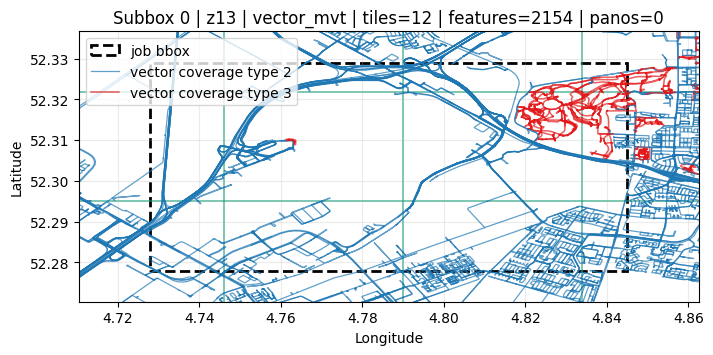

In [109]:
def source_color(source_kind: str) -> str:
    palette = {
        'raster': '#D95F02',
        'vector_mvt': '#1B9E77',
        'coverage_json': '#7570B3',
    }
    return palette.get(source_kind, '#333333')


def parse_linestring_wkt(wkt: str) -> list[list[tuple[float, float]]]:
    if not wkt:
        return []

    wkt = wkt.strip()
    if wkt.startswith('MULTILINESTRING'):
        body = wkt[len('MULTILINESTRING'):].strip()
        if not (body.startswith('(') and body.endswith(')')):
            return []
        inner = body[1:-1].strip()
        if not inner:
            return []
        raw_segments = re.split(r'\)\s*,\s*\(', inner[1:-1])
    elif wkt.startswith('LINESTRING'):
        body = wkt[len('LINESTRING'):].strip()
        if not (body.startswith('(') and body.endswith(')')):
            return []
        raw_segments = [body[1:-1]]
    else:
        return []

    segments = []
    for raw_segment in raw_segments:
        coords = []
        for pair in raw_segment.split(','):
            lon, lat = pair.strip().split()
            coords.append((float(lon), float(lat)))
        if coords:
            segments.append(coords)
    return segments


def vector_feature_style(coverage_type: str) -> tuple[str, float]:
    if str(coverage_type) == '2':
        return '#1F78B4', 0.9
    if str(coverage_type) == '3':
        return '#E31A1C', 1.1
    return '#4D4D4D', 0.8


def plot_result_map(result: dict, figsize: tuple[int, int] = (8, 8), show_tile_labels: bool = False) -> None:
    job = result['job']
    tile_rows = read_csv_rows(Path(result['tile_summary_path']))
    pano_rows = read_csv_rows(Path(result['pano_records_path']))
    vector_rows = read_csv_rows(Path(result['vector_feature_records_path']))
    bbox = job['bbox']

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(
        f"Subbox {job['index']} | z{job['display_zoom']} | {job['source']['kind']} | tiles={len(tile_rows)} | features={len(vector_rows)} | panos={len(pano_rows)}"
    )

    bbox_width = bbox['max_lon'] - bbox['min_lon']
    bbox_height = bbox['max_lat'] - bbox['min_lat']
    ax.add_patch(
        Rectangle(
            (bbox['min_lon'], bbox['min_lat']),
            bbox_width,
            bbox_height,
            fill=False,
            edgecolor='black',
            linewidth=2.0,
            linestyle='--',
            label='job bbox',
        )
    )

    color = source_color(job['source']['kind'])
    for row in tile_rows:
        x = int(row['x'])
        y = int(row['y'])
        source_zoom = int(row['source_zoom'])
        lon_min, lat_min, lon_max, lat_max = tile_to_lonlat_bounds(x, y, source_zoom)
        rect = Rectangle(
            (lon_min, lat_min),
            lon_max - lon_min,
            lat_max - lat_min,
            fill=False,
            edgecolor=color,
            linewidth=1.2,
            alpha=0.4,
        )
        ax.add_patch(rect)
        if show_tile_labels:
            ax.text(
                (lon_min + lon_max) / 2,
                (lat_min + lat_max) / 2,
                f"{x},{y}",
                fontsize=7,
                ha='center',
                va='center',
                color=color,
            )

    vector_legend_added = set()
    for row in vector_rows:
        geometry_wkt = row.get('geometry_wkt', '')
        coverage_type = str(row.get('coverageType', ''))
        line_color, line_width = vector_feature_style(coverage_type)
        label = None
        if coverage_type not in vector_legend_added:
            label = f'vector coverage type {coverage_type or "unknown"}'
            vector_legend_added.add(coverage_type)

        for segment in parse_linestring_wkt(geometry_wkt):
            lons = [point[0] for point in segment]
            lats = [point[1] for point in segment]
            ax.plot(
                lons,
                lats,
                color=line_color,
                linewidth=line_width,
                alpha=0.7,
                label=label,
            )
            label = None

    if pano_rows:
        lons = [float(row['lon']) for row in pano_rows if row['lon']]
        lats = [float(row['lat']) for row in pano_rows if row['lat']]
        if lons and lats:
            ax.scatter(
                lons,
                lats,
                s=10,
                c='#2C3E50',
                alpha=0.7,
                label='panos',
            )

    pad_lon = max(bbox_width * 0.15, 0.002)
    pad_lat = max(bbox_height * 0.15, 0.002)
    ax.set_xlim(bbox['min_lon'] - pad_lon, bbox['max_lon'] + pad_lon)
    ax.set_ylim(bbox['min_lat'] - pad_lat, bbox['max_lat'] + pad_lat)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(alpha=0.25)
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='best')
    plt.show()


def plot_all_results(results_to_plot: list[dict], show_tile_labels: bool = False) -> None:
    if not results_to_plot:
        print('No results available to visualize.')
        return
    for result in results_to_plot:
        plot_result_map(result, show_tile_labels=show_tile_labels)


plot_all_results(results)


## Google Street View Coverage via sv-map MTS Raster

Fetch the Google Street View coverage raster tiles used by the sv-map frontend and visualize the alpha coverage mask.


### Configuration


In [110]:
PROJECT_ROOT = Path('/data/zicheng/2026_global_street_view_coverage')
OUTPUT_ROOT = PROJECT_ROOT / 'data' / 'raw'
OUTPUT_NAMESPACE = 'svmap_google_mts_raster'

AREA_PRESETS = {
    'amsterdam_city_bbox_approx': {
        'min_lon': 4.728,
        'min_lat': 52.278,
        'max_lon': 5.079,
        'max_lat': 52.431,
    },
}

BBOX = dict(AREA_PRESETS['amsterdam_city_bbox_approx'])

SUBDIVIDE_BBOX = True
GRID_ROWS = 3
GRID_COLS = 3
TARGET_SUBBOX = 0
# None -> all subboxes
# 0    -> only the first subbox
# [0, 1, 2] -> selected subboxes

DISPLAY_ZOOM = 13

MTS_URL_TEMPLATE = (
    'https://mts.googleapis.com/vt?pb='
    '!1m4!1m3!1i{z}!2i{x}!3i{y}'
    '!2m8!1e2!2ssvv'
    '!4m2!1scc!2s*211m3*211e2*212b1*213e2*212b1*214b1'
    '!4m2!1ssvl!2s*212b1'
    '!3m11!2sen!3sUS'
    '!12m4!1e68!2m2!1sset!2sRoadmap'
    '!12m3!1e37!2m1!1ssmartmaps'
    '!5m1!5f1.5'
)

REQUEST_HEADERS = {
    'User-Agent': 'global-svi-coverage-observatory-notebook/0.2',
    'Referer': 'https://sv-map.netlify.app/',
}

RUN_LABEL = 'amsterdam_city_grid_svmap_mts'
REQUEST_TIMEOUT_SECONDS = 60
DRY_RUN = False

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print('Configured bbox:', BBOX)
print('Output namespace:', OUTPUT_NAMESPACE)
print('Display zoom:', DISPLAY_ZOOM)
print('SUBDIVIDE_BBOX:', SUBDIVIDE_BBOX)
if SUBDIVIDE_BBOX:
    print('Grid shape:', (GRID_ROWS, GRID_COLS))
    print('Target subbox selector:', TARGET_SUBBOX)


Configured bbox: {'min_lon': 4.728, 'min_lat': 52.278, 'max_lon': 5.079, 'max_lat': 52.431}
Output namespace: svmap_google_mts_raster
Display zoom: 13
SUBDIVIDE_BBOX: True
Grid shape: (3, 3)
Target subbox selector: 0


### Tile Job Builder


In [111]:
if SUBDIVIDE_BBOX:
    all_subboxes = split_bbox_into_grid(BBOX, GRID_ROWS, GRID_COLS)
    selected_subboxes = select_subboxes(all_subboxes, TARGET_SUBBOX)
else:
    all_subboxes = [{'index': 0, 'row': 0, 'col': 0, 'bbox': BBOX}]
    selected_subboxes = all_subboxes

jobs = []
for subbox in selected_subboxes:
    source_tile_range = bbox_to_tile_range(subbox['bbox'], DISPLAY_ZOOM)
    jobs.append({
        'index': subbox['index'],
        'row': subbox['row'],
        'col': subbox['col'],
        'bbox': subbox['bbox'],
        'display_zoom': DISPLAY_ZOOM,
        'source_zoom': DISPLAY_ZOOM,
        'source_tile_range': source_tile_range,
        'source_tile_count': tile_count(source_tile_range),
        'run_label': f"{RUN_LABEL}_subbox_{subbox['index']:02d}",
    })

print('Total subboxes in grid:', len(all_subboxes))
print('Selected jobs:', len(jobs))
for job in jobs:
    print('-' * 72)
    print('Subbox:', job['index'], 'grid=', (job['row'], job['col']))
    print('BBox:', job['bbox'])
    print('Source tile range:', job['source_tile_range'])
    print('Source tile count:', job['source_tile_count'])


Total subboxes in grid: 9
Selected jobs: 1
------------------------------------------------------------------------
Subbox: 0 grid= (0, 0)
BBox: {'min_lon': 4.728, 'max_lon': 4.845, 'min_lat': 52.278, 'max_lat': 52.329}
Source tile range: {'x_min': 4203, 'x_max': 4206, 'y_min': 2693, 'y_max': 2695}
Source tile count: 12


### Fetch Tiles


In [112]:
TILE_SUMMARY_FIELDS = [
    'provider',
    'source_id',
    'display_zoom',
    'source_zoom',
    'x',
    'y',
    'tile_url',
    'content_type',
    'width',
    'height',
    'coverage_pixel_count',
    'total_pixel_count',
    'coverage_ratio',
    'sha256',
    'byte_length',
    'output_path',
    'metadata_path',
    'fetched_at',
]


def fetch_mts_raster_job(
    job: dict,
    template: str,
    headers: dict[str, str],
    timeout_seconds: int,
    output_root: Path,
    output_namespace: str,
) -> dict:
    output_dir = output_root / output_namespace / job['run_label']
    ensure_directory(output_dir)

    fetched_tiles = []
    skipped_tiles = []
    error_tiles = []

    for x, y in iter_tile_coords(job['source_tile_range']):
        tile_url = format_mts_url(template, job['source_zoom'], x, y)
        fetched_at = utc_now_iso()

        try:
            payload, content_type = fetch_png_tile(tile_url, headers, timeout_seconds)
            png_summary = summarize_png(payload)
        except Exception as exc:
            error_tiles.append({
                'provider': output_namespace,
                'source_id': 'svmap_google_mts',
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'reason': repr(exc),
            })
            continue

        if not content_type.startswith('image/png'):
            skipped_tiles.append({
                'provider': output_namespace,
                'source_id': 'svmap_google_mts',
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'content_type': content_type,
            })
            continue

        tile_path = output_dir / 'tiles' / str(job['source_zoom']) / str(x) / f'{y}.png'
        ensure_directory(tile_path.parent)
        tile_path.write_bytes(payload)

        metadata_path = Path(str(tile_path) + '.metadata.json')
        row = {
            'provider': output_namespace,
            'source_id': 'svmap_google_mts',
            'display_zoom': job['display_zoom'],
            'source_zoom': job['source_zoom'],
            'x': x,
            'y': y,
            'tile_url': tile_url,
            'content_type': content_type,
            'width': png_summary['width'],
            'height': png_summary['height'],
            'coverage_pixel_count': png_summary['coverage_pixel_count'],
            'total_pixel_count': png_summary['total_pixel_count'],
            'coverage_ratio': png_summary['coverage_ratio'],
            'sha256': sha256_bytes(payload),
            'byte_length': len(payload),
            'output_path': str(tile_path),
            'metadata_path': str(metadata_path),
            'fetched_at': fetched_at,
        }
        metadata_path.write_text(json.dumps(row, indent=2, sort_keys=True), encoding='utf-8')
        fetched_tiles.append(row)

    tile_summary_path = output_dir / 'tile_summary.csv'
    write_csv(tile_summary_path, fetched_tiles, TILE_SUMMARY_FIELDS)

    manifest = {
        'provider': output_namespace,
        'source_id': 'svmap_google_mts',
        'template': template,
        'request_headers': headers,
        'job_index': job['index'],
        'job_row': job['row'],
        'job_col': job['col'],
        'bbox': job['bbox'],
        'display_zoom': job['display_zoom'],
        'source_zoom': job['source_zoom'],
        'source_tile_range': job['source_tile_range'],
        'source_tile_count': job['source_tile_count'],
        'fetched_tile_count': len(fetched_tiles),
        'skipped_tile_count': len(skipped_tiles),
        'error_tile_count': len(error_tiles),
        'tile_summary_path': str(tile_summary_path),
        'fetched_at': utc_now_iso(),
    }
    manifest_path = output_dir / 'manifest.json'
    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding='utf-8')

    if skipped_tiles:
        (output_dir / 'skipped_tiles.json').write_text(
            json.dumps(skipped_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )
    if error_tiles:
        (output_dir / 'errors.json').write_text(
            json.dumps(error_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )

    return {
        'output_dir': output_dir,
        'tile_summary_path': tile_summary_path,
        'manifest_path': manifest_path,
        'manifest': manifest,
        'fetched_tiles': fetched_tiles,
        'skipped_tiles': skipped_tiles,
        'error_tiles': error_tiles,
        'job': job,
    }


results = []

if DRY_RUN:
    print('DRY_RUN is True. No requests sent.')
else:
    for job in jobs:
        print('Fetching subbox', job['index'], 'at display/source zoom', (job['display_zoom'], job['source_zoom']))
        result = fetch_mts_raster_job(
            job=job,
            template=MTS_URL_TEMPLATE,
            headers=REQUEST_HEADERS,
            timeout_seconds=REQUEST_TIMEOUT_SECONDS,
            output_root=OUTPUT_ROOT,
            output_namespace=OUTPUT_NAMESPACE,
        )
        results.append(result)
        print('Saved to:', result['output_dir'])
        print('Fetched tiles:', result['manifest']['fetched_tile_count'])
        print('Skipped tiles:', result['manifest']['skipped_tile_count'])
        print('Errors:', result['manifest']['error_tile_count'])


Fetching subbox 0 at display/source zoom (13, 13)


Saved to: /data/zicheng/2026_global_street_view_coverage/data/raw/svmap_google_mts_raster/amsterdam_city_grid_svmap_mts_subbox_00
Fetched tiles: 0
Skipped tiles: 0
Errors: 12


### Visualize Results


In [113]:
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def load_rgba_image(path: str) -> np.ndarray:
    with Image.open(path) as image:
        return np.array(image.convert('RGBA'))


def mask_rgba_from_image(rgba: np.ndarray) -> np.ndarray:
    mask = np.zeros_like(rgba)
    alpha = rgba[:, :, 3] > 0
    mask[alpha] = np.array([27, 94, 255, 190], dtype=np.uint8)
    return mask


def plot_mts_raster_result(result: dict, figsize: tuple[int, int] = (14, 7), show_tile_labels: bool = False) -> None:
    job = result['job']
    tile_rows = read_csv_rows(Path(result['tile_summary_path']))
    bbox = job['bbox']

    if not tile_rows:
        print('No fetched tiles found for visualization:', result['tile_summary_path'])
        return

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    ax_raw, ax_mask = axes
    title = (
        f"Subbox {job['index']} | display z{job['display_zoom']} | source z{job['source_zoom']} "
        f"| fetched tiles={len(tile_rows)}"
    )
    ax_raw.set_title(title + ' | raster tiles')
    ax_mask.set_title(title + ' | coverage mask')

    bbox_width = bbox['max_lon'] - bbox['min_lon']
    bbox_height = bbox['max_lat'] - bbox['min_lat']

    for ax in axes:
        ax.add_patch(
            Rectangle(
                (bbox['min_lon'], bbox['min_lat']),
                bbox_width,
                bbox_height,
                fill=False,
                edgecolor='black',
                linewidth=2.0,
                linestyle='--',
            )
        )

    total_coverage_pixels = 0
    total_pixels = 0

    for row in tile_rows:
        x = int(row['x'])
        y = int(row['y'])
        z = int(row['source_zoom'])
        lon_min, lat_min, lon_max, lat_max = tile_to_lonlat_bounds(x, y, z)
        rgba = load_rgba_image(row['output_path'])
        mask_rgba = mask_rgba_from_image(rgba)

        ax_raw.imshow(rgba, extent=[lon_min, lon_max, lat_min, lat_max], origin='upper')
        ax_mask.imshow(mask_rgba, extent=[lon_min, lon_max, lat_min, lat_max], origin='upper')

        for ax in axes:
            ax.add_patch(
                Rectangle(
                    (lon_min, lat_min),
                    lon_max - lon_min,
                    lat_max - lat_min,
                    fill=False,
                    edgecolor='#333333',
                    linewidth=0.8,
                    alpha=0.5,
                )
            )

        if show_tile_labels:
            label_x = (lon_min + lon_max) / 2
            label_y = (lat_min + lat_max) / 2
            label = f"{x},{y}"
            ax_raw.text(label_x, label_y, label, fontsize=7, ha='center', va='center')
            ax_mask.text(label_x, label_y, label, fontsize=7, ha='center', va='center')

        total_coverage_pixels += int(row['coverage_pixel_count'])
        total_pixels += int(row['total_pixel_count'])

    coverage_ratio = total_coverage_pixels / total_pixels if total_pixels else 0.0

    for ax in axes:
        pad_lon = max(bbox_width * 0.15, 0.002)
        pad_lat = max(bbox_height * 0.15, 0.002)
        ax.set_xlim(bbox['min_lon'] - pad_lon, bbox['max_lon'] + pad_lon)
        ax.set_ylim(bbox['min_lat'] - pad_lat, bbox['max_lat'] + pad_lat)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.grid(alpha=0.25)
        ax.set_aspect('equal', adjustable='box')

    fig.suptitle(f'Coverage pixel ratio across fetched tiles: {coverage_ratio:.4f}')
    plt.tight_layout()
    plt.show()


def plot_all_mts_results(results_to_plot: list[dict], show_tile_labels: bool = False) -> None:
    if not results_to_plot:
        print('No results available to visualize.')
        return
    for result in results_to_plot:
        plot_mts_raster_result(result, show_tile_labels=show_tile_labels)


plot_all_mts_results(results)


No fetched tiles found for visualization: /data/zicheng/2026_global_street_view_coverage/data/raw/svmap_google_mts_raster/amsterdam_city_grid_svmap_mts_subbox_00/tile_summary.csv


## KartaView Coverage Raster

Fetch KartaView coverage raster tiles for the same style of bounding-box-driven inspection.


### Configuration


In [114]:
KARTAVIEW_OUTPUT_NAMESPACE = 'kartaview_coverage_raster'
KARTAVIEW_SOURCE_ID = 'kartaview_sequence_tiles'

KARTAVIEW_AREA_PRESETS = {
    'amsterdam_city_bbox_approx': {
        'min_lon': 4.728,
        'min_lat': 52.278,
        'max_lon': 5.079,
        'max_lat': 52.431,
    },
}

KARTAVIEW_BBOX = dict(KARTAVIEW_AREA_PRESETS['amsterdam_city_bbox_approx'])

KARTAVIEW_SUBDIVIDE_BBOX = True
KARTAVIEW_GRID_ROWS = 3
KARTAVIEW_GRID_COLS = 3
KARTAVIEW_TARGET_SUBBOX = 0

KARTAVIEW_DISPLAY_ZOOM = 13
KARTAVIEW_URL_TEMPLATE = 'https://api.openstreetcam.org/2.0/sequence/tiles/{x}/{y}/{z}.png'
KARTAVIEW_REQUEST_HEADERS = {
    'User-Agent': 'global-svi-coverage-observatory-notebook/0.2',
    'Referer': 'https://kartaview.org/',
}
KARTAVIEW_RUN_LABEL = 'amsterdam_city_grid_kartaview'
KARTAVIEW_REQUEST_TIMEOUT_SECONDS = 60
KARTAVIEW_DRY_RUN = False

print('KARTAVIEW_BBOX:', KARTAVIEW_BBOX)
print('KARTAVIEW_DISPLAY_ZOOM:', KARTAVIEW_DISPLAY_ZOOM)
print('KARTAVIEW_SUBDIVIDE_BBOX:', KARTAVIEW_SUBDIVIDE_BBOX)
if KARTAVIEW_SUBDIVIDE_BBOX:
    print('KARTAVIEW grid shape:', (KARTAVIEW_GRID_ROWS, KARTAVIEW_GRID_COLS))
    print('KARTAVIEW target subbox selector:', KARTAVIEW_TARGET_SUBBOX)


KARTAVIEW_BBOX: {'min_lon': 4.728, 'min_lat': 52.278, 'max_lon': 5.079, 'max_lat': 52.431}
KARTAVIEW_DISPLAY_ZOOM: 13
KARTAVIEW_SUBDIVIDE_BBOX: True
KARTAVIEW grid shape: (3, 3)
KARTAVIEW target subbox selector: 0


### Fetch Tiles


In [115]:
KARTAVIEW_TILE_SUMMARY_FIELDS = [
    'provider',
    'source_id',
    'display_zoom',
    'source_zoom',
    'x',
    'y',
    'tile_url',
    'content_type',
    'width',
    'height',
    'coverage_pixel_count',
    'total_pixel_count',
    'coverage_ratio',
    'sha256',
    'byte_length',
    'output_path',
    'metadata_path',
    'fetched_at',
]


if KARTAVIEW_SUBDIVIDE_BBOX:
    kartaview_all_subboxes = split_bbox_into_grid(
        KARTAVIEW_BBOX,
        KARTAVIEW_GRID_ROWS,
        KARTAVIEW_GRID_COLS,
    )
    kartaview_selected_subboxes = select_subboxes(
        kartaview_all_subboxes,
        KARTAVIEW_TARGET_SUBBOX,
    )
else:
    kartaview_all_subboxes = [{'index': 0, 'row': 0, 'col': 0, 'bbox': KARTAVIEW_BBOX}]
    kartaview_selected_subboxes = kartaview_all_subboxes

kartaview_jobs = []
for subbox in kartaview_selected_subboxes:
    source_tile_range = bbox_to_tile_range(subbox['bbox'], KARTAVIEW_DISPLAY_ZOOM)
    kartaview_jobs.append({
        'index': subbox['index'],
        'row': subbox['row'],
        'col': subbox['col'],
        'bbox': subbox['bbox'],
        'display_zoom': KARTAVIEW_DISPLAY_ZOOM,
        'source_zoom': KARTAVIEW_DISPLAY_ZOOM,
        'source_tile_range': source_tile_range,
        'source_tile_count': tile_count(source_tile_range),
        'run_label': f"{KARTAVIEW_RUN_LABEL}_subbox_{subbox['index']:02d}",
    })

print('KartaView total subboxes in grid:', len(kartaview_all_subboxes))
print('KartaView selected jobs:', len(kartaview_jobs))
for job in kartaview_jobs:
    print('-' * 72)
    print('Subbox:', job['index'], 'grid=', (job['row'], job['col']))
    print('BBox:', job['bbox'])
    print('Source tile range:', job['source_tile_range'])
    print('Source tile count:', job['source_tile_count'])


def fetch_kartaview_tile(url: str, headers: dict[str, str], timeout_seconds: int) -> tuple[bytes, str]:
    response = requests.get(url, headers=headers, timeout=timeout_seconds)
    response.raise_for_status()
    return response.content, response.headers.get('Content-Type', '')


def fetch_kartaview_raster_job(
    job: dict,
    template: str,
    headers: dict[str, str],
    timeout_seconds: int,
    output_root: Path,
    output_namespace: str,
) -> dict:
    output_dir = output_root / output_namespace / job['run_label']
    ensure_directory(output_dir)

    fetched_tiles = []
    skipped_tiles = []
    error_tiles = []

    for x, y in iter_tile_coords(job['source_tile_range']):
        tile_url = template.format(x=x, y=y, z=job['source_zoom'])
        fetched_at = utc_now_iso()

        try:
            payload, content_type = fetch_kartaview_tile(tile_url, headers, timeout_seconds)
            png_summary = summarize_png(payload)
        except Exception as exc:
            error_tiles.append({
                'provider': output_namespace,
                'source_id': KARTAVIEW_SOURCE_ID,
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'reason': repr(exc),
            })
            continue

        if not content_type.startswith('image/png'):
            skipped_tiles.append({
                'provider': output_namespace,
                'source_id': KARTAVIEW_SOURCE_ID,
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'content_type': content_type,
            })
            continue

        tile_path = output_dir / 'tiles' / str(job['source_zoom']) / str(x) / f'{y}.png'
        ensure_directory(tile_path.parent)
        tile_path.write_bytes(payload)

        metadata_path = Path(str(tile_path) + '.metadata.json')
        row = {
            'provider': output_namespace,
            'source_id': KARTAVIEW_SOURCE_ID,
            'display_zoom': job['display_zoom'],
            'source_zoom': job['source_zoom'],
            'x': x,
            'y': y,
            'tile_url': tile_url,
            'content_type': content_type,
            'width': png_summary['width'],
            'height': png_summary['height'],
            'coverage_pixel_count': png_summary['coverage_pixel_count'],
            'total_pixel_count': png_summary['total_pixel_count'],
            'coverage_ratio': png_summary['coverage_ratio'],
            'sha256': sha256_bytes(payload),
            'byte_length': len(payload),
            'output_path': str(tile_path),
            'metadata_path': str(metadata_path),
            'fetched_at': fetched_at,
        }
        metadata_path.write_text(json.dumps(row, indent=2, sort_keys=True), encoding='utf-8')
        fetched_tiles.append(row)

    tile_summary_path = output_dir / 'tile_summary.csv'
    write_csv(tile_summary_path, fetched_tiles, KARTAVIEW_TILE_SUMMARY_FIELDS)

    manifest = {
        'provider': output_namespace,
        'source_id': KARTAVIEW_SOURCE_ID,
        'template': template,
        'request_headers': headers,
        'bbox': job['bbox'],
        'display_zoom': job['display_zoom'],
        'source_zoom': job['source_zoom'],
        'source_tile_range': job['source_tile_range'],
        'source_tile_count': job['source_tile_count'],
        'fetched_tile_count': len(fetched_tiles),
        'skipped_tile_count': len(skipped_tiles),
        'error_tile_count': len(error_tiles),
        'tile_summary_path': str(tile_summary_path),
        'fetched_at': utc_now_iso(),
    }
    manifest_path = output_dir / 'manifest.json'
    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding='utf-8')

    if skipped_tiles:
        (output_dir / 'skipped_tiles.json').write_text(
            json.dumps(skipped_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )
    if error_tiles:
        (output_dir / 'errors.json').write_text(
            json.dumps(error_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )

    return {
        'output_dir': output_dir,
        'tile_summary_path': tile_summary_path,
        'manifest_path': manifest_path,
        'manifest': manifest,
        'fetched_tiles': fetched_tiles,
        'skipped_tiles': skipped_tiles,
        'error_tiles': error_tiles,
        'job': job,
    }


kartaview_results = []

if KARTAVIEW_DRY_RUN:
    print('KARTAVIEW_DRY_RUN is True. No requests sent.')
else:
    for job in kartaview_jobs:
        kartaview_result = fetch_kartaview_raster_job(
            job=job,
            template=KARTAVIEW_URL_TEMPLATE,
            headers=KARTAVIEW_REQUEST_HEADERS,
            timeout_seconds=KARTAVIEW_REQUEST_TIMEOUT_SECONDS,
            output_root=OUTPUT_ROOT,
            output_namespace=KARTAVIEW_OUTPUT_NAMESPACE,
        )
        kartaview_results.append(kartaview_result)
        print('Saved to:', kartaview_result['output_dir'])
        print('Fetched tiles:', kartaview_result['manifest']['fetched_tile_count'])
        print('Skipped tiles:', kartaview_result['manifest']['skipped_tile_count'])
        print('Errors:', kartaview_result['manifest']['error_tile_count'])


KartaView total subboxes in grid: 9
KartaView selected jobs: 1
------------------------------------------------------------------------
Subbox: 0 grid= (0, 0)
BBox: {'min_lon': 4.728, 'max_lon': 4.845, 'min_lat': 52.278, 'max_lat': 52.329}
Source tile range: {'x_min': 4203, 'x_max': 4206, 'y_min': 2693, 'y_max': 2695}
Source tile count: 12
Saved to: /data/zicheng/2026_global_street_view_coverage/data/raw/kartaview_coverage_raster/amsterdam_city_grid_kartaview_subbox_00
Fetched tiles: 0
Skipped tiles: 0
Errors: 12


### Visualize Results


In [116]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def kartaview_load_rgba_image(path: str) -> np.ndarray:
    with Image.open(path) as image:
        return np.array(image.convert('RGBA'))


def kartaview_mask_rgba_from_image(rgba: np.ndarray) -> np.ndarray:
    mask = np.zeros_like(rgba)
    alpha = rgba[:, :, 3] > 0
    mask[alpha] = np.array([27, 94, 255, 190], dtype=np.uint8)
    return mask


def plot_kartaview_raster_result(result: dict, figsize: tuple[int, int] = (14, 7), show_tile_labels: bool = True) -> None:
    tile_rows = read_csv_rows(Path(result['tile_summary_path']))
    bbox = result['job']['bbox']

    if not tile_rows:
        print('No fetched KartaView tiles found for visualization:', result['tile_summary_path'])
        return

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    ax_raw, ax_mask = axes
    title = (
        f"KartaView subbox {result['job']['index']:02d} | "
        f"z{result['job']['source_zoom']} | "
        f"tiles={len(tile_rows)}"
    )
    ax_raw.set_title(title + ' | raster tiles')
    ax_mask.set_title(title + ' | coverage mask')

    bbox_width = bbox['max_lon'] - bbox['min_lon']
    bbox_height = bbox['max_lat'] - bbox['min_lat']

    for ax in axes:
        ax.add_patch(
            Rectangle(
                (bbox['min_lon'], bbox['min_lat']),
                bbox_width,
                bbox_height,
                fill=False,
                edgecolor='black',
                linewidth=2.0,
                linestyle='--',
            )
        )

    total_coverage_pixels = 0
    total_pixels = 0

    for row in tile_rows:
        x = int(row['x'])
        y = int(row['y'])
        z = int(row['source_zoom'])
        lon_min, lat_min, lon_max, lat_max = tile_to_lonlat_bounds(x, y, z)
        rgba = kartaview_load_rgba_image(row['output_path'])
        mask_rgba = kartaview_mask_rgba_from_image(rgba)

        ax_raw.imshow(rgba, extent=[lon_min, lon_max, lat_min, lat_max], origin='upper')
        ax_mask.imshow(mask_rgba, extent=[lon_min, lon_max, lat_min, lat_max], origin='upper')

        for ax in axes:
            ax.add_patch(
                Rectangle(
                    (lon_min, lat_min),
                    lon_max - lon_min,
                    lat_max - lat_min,
                    fill=False,
                    edgecolor='#333333',
                    linewidth=0.8,
                    alpha=0.5,
                )
            )

        if show_tile_labels:
            label_x = (lon_min + lon_max) / 2
            label_y = (lat_min + lat_max) / 2
            label = f"{x},{y}"
            ax_raw.text(label_x, label_y, label, fontsize=7, ha='center', va='center')
            ax_mask.text(label_x, label_y, label, fontsize=7, ha='center', va='center')

        total_coverage_pixels += int(row['coverage_pixel_count'])
        total_pixels += int(row['total_pixel_count'])

    coverage_ratio = total_coverage_pixels / total_pixels if total_pixels else 0.0

    for ax in axes:
        pad_lon = max(bbox_width * 0.15, 0.002)
        pad_lat = max(bbox_height * 0.15, 0.002)
        ax.set_xlim(bbox['min_lon'] - pad_lon, bbox['max_lon'] + pad_lon)
        ax.set_ylim(bbox['min_lat'] - pad_lat, bbox['max_lat'] + pad_lat)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.grid(alpha=0.25)
        ax.set_aspect('equal', adjustable='box')

    fig.suptitle(f'Coverage pixel ratio across fetched KartaView tiles: {coverage_ratio:.4f}')
    plt.tight_layout()
    plt.show()


def plot_all_kartaview_results(results_to_plot: list[dict], show_tile_labels: bool = True) -> None:
    if not results_to_plot:
        print('No KartaView results available to visualize.')
        return
    for result in results_to_plot:
        plot_kartaview_raster_result(result, show_tile_labels=show_tile_labels)


plot_all_kartaview_results(kartaview_results)


No fetched KartaView tiles found for visualization: /data/zicheng/2026_global_street_view_coverage/data/raw/kartaview_coverage_raster/amsterdam_city_grid_kartaview_subbox_00/tile_summary.csv


## Panoramax MVT Coverage

Fetch and decode Panoramax vector tiles, then visualize decoded coverage features.


### Configuration


In [117]:
PANORAMAX_OUTPUT_NAMESPACE = 'panoramax_mvt_coverage'
PANORAMAX_SOURCE_ID = 'panoramax_xyz_mvt'

PANORAMAX_AREA_PRESETS = {
    'amsterdam_city_bbox_approx': {
        'min_lon': 4.728,
        'min_lat': 52.278,
        'max_lon': 5.079,
        'max_lat': 52.431,
    },
}

PANORAMAX_BBOX = dict(PANORAMAX_AREA_PRESETS['amsterdam_city_bbox_approx'])

PANORAMAX_SUBDIVIDE_BBOX = True
PANORAMAX_GRID_ROWS = 3
PANORAMAX_GRID_COLS = 3
PANORAMAX_TARGET_SUBBOX = 0

PANORAMAX_DISPLAY_ZOOM = 13
PANORAMAX_URL_TEMPLATE = 'https://api.panoramax.xyz/api/map/{z}/{x}/{y}.mvt'
PANORAMAX_REQUEST_HEADERS = {
    'User-Agent': 'global-svi-coverage-observatory-notebook/0.2',
    'Accept': 'application/vnd.mapbox-vector-tile, application/octet-stream;q=0.9, */*;q=0.1',
    'Referer': 'https://api.panoramax.xyz/en/index?focus=map',
}
PANORAMAX_RUN_LABEL = 'amsterdam_city_grid_panoramax'
PANORAMAX_REQUEST_TIMEOUT_SECONDS = 60
PANORAMAX_DRY_RUN = False

print('PANORAMAX_BBOX:', PANORAMAX_BBOX)
print('PANORAMAX_DISPLAY_ZOOM:', PANORAMAX_DISPLAY_ZOOM)
print('PANORAMAX_SUBDIVIDE_BBOX:', PANORAMAX_SUBDIVIDE_BBOX)
if PANORAMAX_SUBDIVIDE_BBOX:
    print('PANORAMAX grid shape:', (PANORAMAX_GRID_ROWS, PANORAMAX_GRID_COLS))
    print('PANORAMAX target subbox selector:', PANORAMAX_TARGET_SUBBOX)


PANORAMAX_BBOX: {'min_lon': 4.728, 'min_lat': 52.278, 'max_lon': 5.079, 'max_lat': 52.431}
PANORAMAX_DISPLAY_ZOOM: 13
PANORAMAX_SUBDIVIDE_BBOX: True
PANORAMAX grid shape: (3, 3)
PANORAMAX target subbox selector: 0


### Fetch and Decode Tiles


In [118]:
import ast
import importlib.util
import re
import urllib.request
from google.protobuf import descriptor_pool, message_factory
from urllib.error import HTTPError, URLError


PANORAMAX_TILE_SUMMARY_FIELDS = [
    'provider',
    'source_id',
    'display_zoom',
    'source_zoom',
    'x',
    'y',
    'tile_url',
    'content_type',
    'byte_length',
    'feature_count',
    'layer_counts_json',
    'sha256',
    'output_path',
    'metadata_path',
    'fetched_at',
]

PANORAMAX_FEATURE_RECORD_FIELDS = [
    'provider',
    'source_id',
    'display_zoom',
    'source_zoom',
    'tile_x',
    'tile_y',
    'tile_url',
    'layer_name',
    'feature_index',
    'mvt_id',
    'geometry_type',
    'properties_json',
    'geometry_wkt',
    'fetched_at',
]


def panoramax_fetch_tile(url: str, headers: dict[str, str], timeout_seconds: int) -> tuple[bytes, str]:
    request = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(request, timeout=timeout_seconds) as response:
        return response.read(), response.headers.get('Content-Type', '')


def load_vector_tile_message_class():
    package_spec = importlib.util.find_spec('mapbox_vector_tile')
    if not package_spec or not package_spec.submodule_search_locations:
        raise RuntimeError('mapbox_vector_tile package is required for locating vector_tile protobuf schema files.')

    package_dir = Path(list(package_spec.submodule_search_locations)[0])
    pb2_path = package_dir / 'Mapbox' / 'vector_tile_p3_pb2.py'
    if not pb2_path.exists():
        raise RuntimeError(f'Could not locate vector_tile protobuf module at {pb2_path}.')

    source = pb2_path.read_text(encoding='utf-8')
    match = re.search(r"serialized_pb=(b'.*?')\n\)", source, re.S)
    if not match:
        raise RuntimeError(f'Could not locate serialized_pb descriptor bytes in {pb2_path}.')

    serialized_pb = ast.literal_eval(match.group(1))
    pool = descriptor_pool.DescriptorPool()
    pool.AddSerializedFile(serialized_pb)
    tile_descriptor = pool.FindMessageTypeByName('mapnik.vector.tile')
    if hasattr(message_factory, 'GetMessageClass'):
        return message_factory.GetMessageClass(tile_descriptor)
    return message_factory.MessageFactory(pool).GetPrototype(tile_descriptor)


PANORAMAX_TILE_MESSAGE_CLASS = load_vector_tile_message_class()

PANORAMAX_CMD_MOVE_TO = 1
PANORAMAX_CMD_LINE_TO = 2
PANORAMAX_CMD_SEG_END = 7

PANORAMAX_POINT = 1
PANORAMAX_LINESTRING = 2
PANORAMAX_POLYGON = 3


def panoramax_parse_value(val) -> object:
    for candidate in (
        'bool_value',
        'double_value',
        'float_value',
        'int_value',
        'sint_value',
        'string_value',
        'uint_value',
    ):
        if val.HasField(candidate):
            return getattr(val, candidate)
    return None


def panoramax_zig_zag_decode(n: int) -> int:
    return (n >> 1) ^ (-(n & 1))


def panoramax_parse_geometry(geom, ftype: int, extent: int) -> dict:
    i = 0
    coords = []
    parts = []
    dx = 0
    dy = 0

    def ensure_polygon_closed(points: list[list[int]]) -> None:
        if points and points[0] != points[-1]:
            points.append(points[0])

    while i != len(geom):
        item = geom[i]
        cmd = item & 0x7
        cmd_len = item >> 3
        i += 1

        if cmd == PANORAMAX_CMD_SEG_END:
            if ftype == PANORAMAX_POLYGON:
                ensure_polygon_closed(coords)
            parts.append(coords)
            coords = []
        elif cmd in (PANORAMAX_CMD_MOVE_TO, PANORAMAX_CMD_LINE_TO):
            if coords and cmd == PANORAMAX_CMD_MOVE_TO and ftype in (PANORAMAX_LINESTRING, PANORAMAX_POLYGON):
                if ftype == PANORAMAX_POLYGON:
                    ensure_polygon_closed(coords)
                parts.append(coords)
                coords = []

            for _ in range(cmd_len):
                x = panoramax_zig_zag_decode(geom[i])
                y = panoramax_zig_zag_decode(geom[i + 1])
                i += 2

                x += dx
                y += dy
                dx = x
                dy = y
                # MVT tile coordinates are already top-down.
                # Keep y as-is before XYZ -> lon/lat conversion.
                coords.append([x, y])
        else:
            raise RuntimeError(f'Unsupported MVT geometry command: {cmd}')

    if ftype == PANORAMAX_POINT:
        if len(coords) == 1:
            return {'type': 'Point', 'coordinates': coords[0]}
        return {'type': 'MultiPoint', 'coordinates': coords}

    if ftype == PANORAMAX_LINESTRING:
        if parts:
            if coords:
                parts.append(coords)
            if len(parts) == 1:
                return {'type': 'LineString', 'coordinates': parts[0]}
            return {'type': 'MultiLineString', 'coordinates': parts}
        return {'type': 'LineString', 'coordinates': coords}

    if ftype == PANORAMAX_POLYGON:
        if coords:
            parts.append(coords)
        return {'type': 'Polygon', 'coordinates': parts}

    return {'type': 'Unknown', 'coordinates': coords}


def panoramax_decode_tile(payload: bytes) -> dict:
    tile = PANORAMAX_TILE_MESSAGE_CLASS()
    tile.ParseFromString(payload)

    decoded = {}
    for layer in tile.layers:
        features = []
        for feature in layer.features:
            props = {}
            tags = list(feature.tags)
            for key_idx, val_idx in zip(tags[::2], tags[1::2]):
                props[layer.keys[key_idx]] = panoramax_parse_value(layer.values[val_idx])

            features.append({
                'id': feature.id,
                'geometry': panoramax_parse_geometry(feature.geometry, feature.type, layer.extent),
                'properties': props,
            })

        decoded[layer.name] = {
            'extent': layer.extent,
            'version': layer.version,
            'feature_count': len(features),
            'features': features,
        }
    return decoded


def panoramax_tile_point_to_lonlat(tile_x: int, tile_y: int, zoom: int, extent: int, point: list[float]) -> tuple[float, float]:
    world_size = extent * (2 ** zoom)
    world_x = tile_x * extent + point[0]
    world_y = tile_y * extent + point[1]
    lon = world_x / world_size * 360.0 - 180.0
    lat = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * world_y / world_size))))
    return lon, lat


def panoramax_transform_geometry_to_lonlat(geometry: dict, tile_x: int, tile_y: int, zoom: int, extent: int) -> dict:
    geometry_type = geometry.get('type', 'Unknown')
    coords = geometry.get('coordinates', [])

    if geometry_type == 'Point':
        lon, lat = panoramax_tile_point_to_lonlat(tile_x, tile_y, zoom, extent, coords)
        return {'type': 'Point', 'coordinates': [lon, lat]}

    if geometry_type == 'MultiPoint':
        return {
            'type': 'MultiPoint',
            'coordinates': [
                list(panoramax_tile_point_to_lonlat(tile_x, tile_y, zoom, extent, point))
                for point in coords
            ],
        }

    if geometry_type == 'LineString':
        return {
            'type': 'LineString',
            'coordinates': [
                list(panoramax_tile_point_to_lonlat(tile_x, tile_y, zoom, extent, point))
                for point in coords
            ],
        }

    if geometry_type == 'MultiLineString':
        return {
            'type': 'MultiLineString',
            'coordinates': [
                [
                    list(panoramax_tile_point_to_lonlat(tile_x, tile_y, zoom, extent, point))
                    for point in line
                ]
                for line in coords
            ],
        }

    if geometry_type == 'Polygon':
        return {
            'type': 'Polygon',
            'coordinates': [
                [
                    list(panoramax_tile_point_to_lonlat(tile_x, tile_y, zoom, extent, point))
                    for point in ring
                ]
                for ring in coords
            ],
        }

    return {'type': geometry_type, 'coordinates': coords}


def panoramax_geometry_to_wkt(geometry: dict) -> str:
    geometry_type = geometry.get('type', 'Unknown')
    coords = geometry.get('coordinates', [])

    def fmt_point(point: list[float]) -> str:
        return f"{point[0]:.8f} {point[1]:.8f}"

    if geometry_type == 'Point':
        return f"POINT ({fmt_point(coords)})"
    if geometry_type == 'MultiPoint':
        inner = ', '.join(f'({fmt_point(point)})' for point in coords)
        return f"MULTIPOINT ({inner})"
    if geometry_type == 'LineString':
        inner = ', '.join(fmt_point(point) for point in coords)
        return f"LINESTRING ({inner})"
    if geometry_type == 'MultiLineString':
        inner = ', '.join(
            '(' + ', '.join(fmt_point(point) for point in line) + ')'
            for line in coords
        )
        return f"MULTILINESTRING ({inner})"
    if geometry_type == 'Polygon':
        inner = ', '.join(
            '(' + ', '.join(fmt_point(point) for point in ring) + ')'
            for ring in coords
        )
        return f"POLYGON ({inner})"
    return ''


if PANORAMAX_SUBDIVIDE_BBOX:
    panoramax_all_subboxes = split_bbox_into_grid(
        PANORAMAX_BBOX,
        PANORAMAX_GRID_ROWS,
        PANORAMAX_GRID_COLS,
    )
    panoramax_selected_subboxes = select_subboxes(
        panoramax_all_subboxes,
        PANORAMAX_TARGET_SUBBOX,
    )
else:
    panoramax_all_subboxes = [{'index': 0, 'row': 0, 'col': 0, 'bbox': PANORAMAX_BBOX}]
    panoramax_selected_subboxes = panoramax_all_subboxes

panoramax_jobs = []
for subbox in panoramax_selected_subboxes:
    source_tile_range = bbox_to_tile_range(subbox['bbox'], PANORAMAX_DISPLAY_ZOOM)
    panoramax_jobs.append({
        'index': subbox['index'],
        'row': subbox['row'],
        'col': subbox['col'],
        'bbox': subbox['bbox'],
        'display_zoom': PANORAMAX_DISPLAY_ZOOM,
        'source_zoom': PANORAMAX_DISPLAY_ZOOM,
        'source_tile_range': source_tile_range,
        'source_tile_count': tile_count(source_tile_range),
        'run_label': f"{PANORAMAX_RUN_LABEL}_subbox_{subbox['index']:02d}",
    })

print('Panoramax total subboxes in grid:', len(panoramax_all_subboxes))
print('Panoramax selected jobs:', len(panoramax_jobs))
for job in panoramax_jobs:
    print('-' * 72)
    print('Subbox:', job['index'], 'grid=', (job['row'], job['col']))
    print('BBox:', job['bbox'])
    print('Source tile range:', job['source_tile_range'])
    print('Source tile count:', job['source_tile_count'])


def fetch_panoramax_mvt_job(
    job: dict,
    template: str,
    headers: dict[str, str],
    timeout_seconds: int,
    output_root: Path,
    output_namespace: str,
) -> dict:
    output_dir = output_root / output_namespace / job['run_label']
    ensure_directory(output_dir)

    fetched_tiles = []
    skipped_tiles = []
    error_tiles = []
    feature_records = []

    for x, y in iter_tile_coords(job['source_tile_range']):
        tile_url = template.format(x=x, y=y, z=job['source_zoom'])
        fetched_at = utc_now_iso()

        try:
            payload, content_type = panoramax_fetch_tile(tile_url, headers, timeout_seconds)
        except HTTPError as exc:
            skipped_or_error = {
                'provider': output_namespace,
                'source_id': PANORAMAX_SOURCE_ID,
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'http_status': exc.code,
                'reason': str(exc.reason),
            }
            if exc.code == 404:
                skipped_tiles.append(skipped_or_error)
            else:
                error_tiles.append(skipped_or_error)
            continue
        except URLError as exc:
            error_tiles.append({
                'provider': output_namespace,
                'source_id': PANORAMAX_SOURCE_ID,
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'reason': str(exc.reason),
            })
            continue
        except Exception as exc:
            error_tiles.append({
                'provider': output_namespace,
                'source_id': PANORAMAX_SOURCE_ID,
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'reason': repr(exc),
            })
            continue

        tile_path = output_dir / 'vector_mvt' / str(job['source_zoom']) / str(x) / f'{y}.mvt'
        ensure_directory(tile_path.parent)
        tile_path.write_bytes(payload)

        decoded_tile = panoramax_decode_tile(payload)
        layer_counts = {
            layer_name: layer_payload.get('feature_count', 0)
            for layer_name, layer_payload in decoded_tile.items()
        }
        feature_count = sum(layer_counts.values())

        for layer_name, layer_payload in decoded_tile.items():
            extent = int(layer_payload.get('extent', 4096) or 4096)
            for feature_index, feature in enumerate(layer_payload.get('features', [])):
                lonlat_geometry = panoramax_transform_geometry_to_lonlat(
                    feature.get('geometry', {}),
                    tile_x=x,
                    tile_y=y,
                    zoom=job['source_zoom'],
                    extent=extent,
                )
                feature_records.append({
                    'provider': output_namespace,
                    'source_id': PANORAMAX_SOURCE_ID,
                    'display_zoom': job['display_zoom'],
                    'source_zoom': job['source_zoom'],
                    'tile_x': x,
                    'tile_y': y,
                    'tile_url': tile_url,
                    'layer_name': layer_name,
                    'feature_index': feature_index,
                    'mvt_id': feature.get('id', ''),
                    'geometry_type': lonlat_geometry.get('type', ''),
                    'properties_json': json.dumps(feature.get('properties', {}), ensure_ascii=False, sort_keys=True),
                    'geometry_wkt': panoramax_geometry_to_wkt(lonlat_geometry),
                    'fetched_at': fetched_at,
                })

        metadata_path = Path(str(tile_path) + '.metadata.json')
        tile_summary_row = {
            'provider': output_namespace,
            'source_id': PANORAMAX_SOURCE_ID,
            'display_zoom': job['display_zoom'],
            'source_zoom': job['source_zoom'],
            'x': x,
            'y': y,
            'tile_url': tile_url,
            'content_type': content_type,
            'byte_length': len(payload),
            'feature_count': feature_count,
            'layer_counts_json': json.dumps(layer_counts, ensure_ascii=False, sort_keys=True),
            'sha256': sha256_bytes(payload),
            'output_path': str(tile_path),
            'metadata_path': str(metadata_path),
            'fetched_at': fetched_at,
        }
        metadata_path.write_text(json.dumps(tile_summary_row, indent=2, sort_keys=True), encoding='utf-8')
        fetched_tiles.append(tile_summary_row)

    tile_summary_path = output_dir / 'tile_summary.csv'
    write_csv(tile_summary_path, fetched_tiles, PANORAMAX_TILE_SUMMARY_FIELDS)

    feature_records_path = output_dir / 'feature_records.csv'
    write_csv(feature_records_path, feature_records, PANORAMAX_FEATURE_RECORD_FIELDS)

    manifest = {
        'provider': output_namespace,
        'source_id': PANORAMAX_SOURCE_ID,
        'template': template,
        'request_headers': headers,
        'bbox': job['bbox'],
        'display_zoom': job['display_zoom'],
        'source_zoom': job['source_zoom'],
        'source_tile_range': job['source_tile_range'],
        'source_tile_count': job['source_tile_count'],
        'fetched_tile_count': len(fetched_tiles),
        'skipped_tile_count': len(skipped_tiles),
        'error_tile_count': len(error_tiles),
        'feature_record_count': len(feature_records),
        'tile_summary_path': str(tile_summary_path),
        'feature_records_path': str(feature_records_path),
        'fetched_at': utc_now_iso(),
    }
    manifest_path = output_dir / 'manifest.json'
    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding='utf-8')

    if skipped_tiles:
        (output_dir / 'skipped_tiles.json').write_text(
            json.dumps(skipped_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )
    if error_tiles:
        (output_dir / 'errors.json').write_text(
            json.dumps(error_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )

    return {
        'output_dir': output_dir,
        'tile_summary_path': tile_summary_path,
        'feature_records_path': feature_records_path,
        'manifest_path': manifest_path,
        'manifest': manifest,
        'fetched_tiles': fetched_tiles,
        'feature_records': feature_records,
        'skipped_tiles': skipped_tiles,
        'error_tiles': error_tiles,
        'job': job,
    }


panoramax_results = []

if PANORAMAX_DRY_RUN:
    print('PANORAMAX_DRY_RUN is True. No requests sent.')
else:
    for job in panoramax_jobs:
        panoramax_result = fetch_panoramax_mvt_job(
            job=job,
            template=PANORAMAX_URL_TEMPLATE,
            headers=PANORAMAX_REQUEST_HEADERS,
            timeout_seconds=PANORAMAX_REQUEST_TIMEOUT_SECONDS,
            output_root=OUTPUT_ROOT,
            output_namespace=PANORAMAX_OUTPUT_NAMESPACE,
        )
        panoramax_results.append(panoramax_result)
        print('Saved to:', panoramax_result['output_dir'])
        print('Fetched tiles:', panoramax_result['manifest']['fetched_tile_count'])
        print('Skipped tiles:', panoramax_result['manifest']['skipped_tile_count'])
        print('Errors:', panoramax_result['manifest']['error_tile_count'])
        print('Decoded features:', panoramax_result['manifest']['feature_record_count'])


Panoramax total subboxes in grid: 9
Panoramax selected jobs: 1
------------------------------------------------------------------------
Subbox: 0 grid= (0, 0)
BBox: {'min_lon': 4.728, 'max_lon': 4.845, 'min_lat': 52.278, 'max_lat': 52.329}
Source tile range: {'x_min': 4203, 'x_max': 4206, 'y_min': 2693, 'y_max': 2695}
Source tile count: 12
Saved to: /data/zicheng/2026_global_street_view_coverage/data/raw/panoramax_mvt_coverage/amsterdam_city_grid_panoramax_subbox_00
Fetched tiles: 12
Skipped tiles: 0
Errors: 0
Decoded features: 559


### Visualize Results


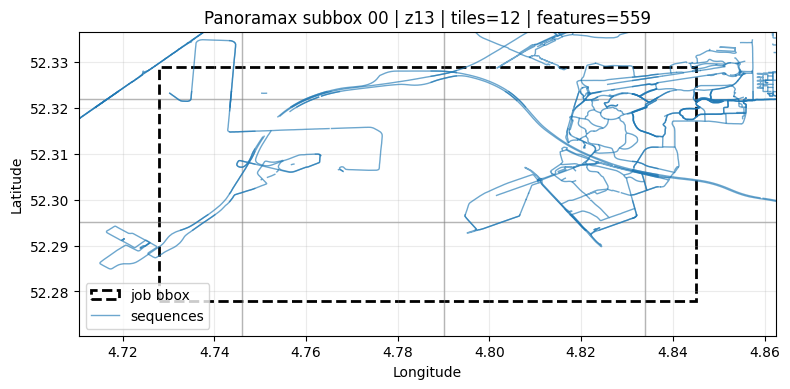

In [119]:
import os
import re
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def panoramax_read_csv_rows(path: Path) -> list[dict]:
    if not path.exists():
        return []
    with path.open('r', newline='', encoding='utf-8') as handle:
        return list(csv.DictReader(handle))


def panoramax_parse_point_wkt(wkt: str) -> tuple[float, float] | None:
    if not wkt:
        return None
    wkt = wkt.strip()
    if not wkt.startswith('POINT'):
        return None
    body = wkt[len('POINT'):].strip()
    if not (body.startswith('(') and body.endswith(')')):
        return None
    lon, lat = body[1:-1].strip().split()
    return float(lon), float(lat)


def panoramax_parse_linestring_wkt(wkt: str) -> list[list[tuple[float, float]]]:
    if not wkt:
        return []

    wkt = wkt.strip()
    if wkt.startswith('MULTILINESTRING'):
        body = wkt[len('MULTILINESTRING'):].strip()
        if not (body.startswith('(') and body.endswith(')')):
            return []
        inner = body[1:-1].strip()
        if not inner:
            return []
        raw_segments = re.split(r'\)\s*,\s*\(', inner[1:-1])
    elif wkt.startswith('LINESTRING'):
        body = wkt[len('LINESTRING'):].strip()
        if not (body.startswith('(') and body.endswith(')')):
            return []
        raw_segments = [body[1:-1]]
    else:
        return []

    segments = []
    for raw_segment in raw_segments:
        coords = []
        for pair in raw_segment.split(','):
            lon, lat = pair.strip().split()
            coords.append((float(lon), float(lat)))
        if coords:
            segments.append(coords)
    return segments


def panoramax_layer_style(layer_name: str) -> tuple[str, float]:
    palette = {
        'sequences': ('#1F78B4', 1.0),
        'pictures': ('#E31A1C', 0.8),
        'grid': ('#33A02C', 0.7),
    }
    return palette.get(layer_name, ('#4D4D4D', 0.8))


def plot_panoramax_result(result: dict, figsize: tuple[int, int] = (9, 9), show_tile_labels: bool = False) -> None:
    tile_rows = panoramax_read_csv_rows(Path(result['tile_summary_path']))
    feature_rows = panoramax_read_csv_rows(Path(result['feature_records_path']))
    bbox = result['job']['bbox']

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(
        f"Panoramax subbox {result['job']['index']:02d} | z{result['job']['source_zoom']} | "
        f"tiles={len(tile_rows)} | features={len(feature_rows)}"
    )

    bbox_width = bbox['max_lon'] - bbox['min_lon']
    bbox_height = bbox['max_lat'] - bbox['min_lat']
    ax.add_patch(
        Rectangle(
            (bbox['min_lon'], bbox['min_lat']),
            bbox_width,
            bbox_height,
            fill=False,
            edgecolor='black',
            linewidth=2.0,
            linestyle='--',
            label='job bbox',
        )
    )

    for row in tile_rows:
        x = int(row['x'])
        y = int(row['y'])
        z = int(row['source_zoom'])
        lon_min, lat_min, lon_max, lat_max = tile_to_lonlat_bounds(x, y, z)
        ax.add_patch(
            Rectangle(
                (lon_min, lat_min),
                lon_max - lon_min,
                lat_max - lat_min,
                fill=False,
                edgecolor='#7F7F7F',
                linewidth=1.0,
                alpha=0.35,
            )
        )
        if show_tile_labels:
            ax.text(
                (lon_min + lon_max) / 2,
                (lat_min + lat_max) / 2,
                f"{x},{y}",
                fontsize=7,
                ha='center',
                va='center',
                color='#666666',
            )

    seen_labels = set()
    point_groups = {}

    for row in feature_rows:
        layer_name = row.get('layer_name', 'unknown')
        geometry_type = row.get('geometry_type', '')
        color, width = panoramax_layer_style(layer_name)

        if geometry_type in ('LineString', 'MultiLineString'):
            label = None
            if layer_name not in seen_labels:
                label = layer_name
                seen_labels.add(layer_name)
            for segment in panoramax_parse_linestring_wkt(row.get('geometry_wkt', '')):
                lons = [point[0] for point in segment]
                lats = [point[1] for point in segment]
                ax.plot(lons, lats, color=color, linewidth=width, alpha=0.65, label=label)
                label = None
        elif geometry_type in ('Point', 'MultiPoint'):
            point = panoramax_parse_point_wkt(row.get('geometry_wkt', ''))
            if point is not None:
                point_groups.setdefault(layer_name, []).append(point)

    for layer_name, points in point_groups.items():
        color, _ = panoramax_layer_style(layer_name)
        xs = [point[0] for point in points]
        ys = [point[1] for point in points]
        ax.scatter(xs, ys, s=10, c=color, alpha=0.7, label=layer_name if layer_name not in seen_labels else None)
        seen_labels.add(layer_name)

    pad_lon = max(bbox_width * 0.15, 0.002)
    pad_lat = max(bbox_height * 0.15, 0.002)
    ax.set_xlim(bbox['min_lon'] - pad_lon, bbox['max_lon'] + pad_lon)
    ax.set_ylim(bbox['min_lat'] - pad_lat, bbox['max_lat'] + pad_lat)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(alpha=0.25)
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='best')
    plt.show()


def plot_all_panoramax_results(results_to_plot: list[dict], show_tile_labels: bool = False) -> None:
    if not results_to_plot:
        print('No Panoramax results available to visualize.')
        return
    for result in results_to_plot:
        plot_panoramax_result(result, show_tile_labels=show_tile_labels)


plot_all_panoramax_results(panoramax_results)


## Mapillary MVT Coverage

Fetch and decode Mapillary coverage vector tiles. Set `MAPILLARY_ACCESS_TOKEN` before running this section.


### Configuration


In [120]:
MAPILLARY_OUTPUT_NAMESPACE = 'mapillary_mvt_coverage'
MAPILLARY_SOURCE_ID = 'mapillary_mly1_public_vtp'

MAPILLARY_AREA_PRESETS = {
    'amsterdam_city_bbox_approx': {
        'min_lon': 4.728,
        'min_lat': 52.278,
        'max_lon': 5.079,
        'max_lat': 52.431,
    },
}

MAPILLARY_BBOX = dict(MAPILLARY_AREA_PRESETS['amsterdam_city_bbox_approx'])

MAPILLARY_SUBDIVIDE_BBOX = True
MAPILLARY_GRID_ROWS = 3
MAPILLARY_GRID_COLS = 3
MAPILLARY_TARGET_SUBBOX = 0

MAPILLARY_DISPLAY_ZOOM = 13
MAPILLARY_URL_TEMPLATE = 'https://tiles.mapillary.com/maps/vtp/mly1_public/2/{z}/{x}/{y}'
MAPILLARY_ACCESS_TOKEN = "MLY|8443722902364390|832fa01211e391f5fd88c8a6186d2ff8"
MAPILLARY_REQUEST_HEADERS = {
    'User-Agent': 'global-svi-coverage-observatory-notebook/0.2',
    'Accept': 'application/vnd.mapbox-vector-tile, application/octet-stream;q=0.9, */*;q=0.1',
    'Referer': 'https://www.mapillary.com/',
}
MAPILLARY_RUN_LABEL = 'amsterdam_city_grid_mapillary'
MAPILLARY_REQUEST_TIMEOUT_SECONDS = 60
MAPILLARY_DRY_RUN = False

print('MAPILLARY_BBOX:', MAPILLARY_BBOX)
print('MAPILLARY_DISPLAY_ZOOM:', MAPILLARY_DISPLAY_ZOOM)
print('MAPILLARY_SUBDIVIDE_BBOX:', MAPILLARY_SUBDIVIDE_BBOX)
if MAPILLARY_SUBDIVIDE_BBOX:
    print('MAPILLARY grid shape:', (MAPILLARY_GRID_ROWS, MAPILLARY_GRID_COLS))
    print('MAPILLARY target subbox selector:', MAPILLARY_TARGET_SUBBOX)
print('MAPILLARY_ACCESS_TOKEN configured:', bool(MAPILLARY_ACCESS_TOKEN))


MAPILLARY_BBOX: {'min_lon': 4.728, 'min_lat': 52.278, 'max_lon': 5.079, 'max_lat': 52.431}
MAPILLARY_DISPLAY_ZOOM: 13
MAPILLARY_SUBDIVIDE_BBOX: True
MAPILLARY grid shape: (3, 3)
MAPILLARY target subbox selector: 0
MAPILLARY_ACCESS_TOKEN configured: True


### Fetch and Decode Tiles


In [121]:
import ast
import importlib.util
import re
import urllib.parse
import urllib.request
from google.protobuf import descriptor_pool, message_factory
from urllib.error import HTTPError, URLError


MAPILLARY_TILE_SUMMARY_FIELDS = [
    'provider',
    'source_id',
    'display_zoom',
    'source_zoom',
    'x',
    'y',
    'tile_url',
    'content_type',
    'byte_length',
    'feature_count',
    'layer_counts_json',
    'sha256',
    'output_path',
    'metadata_path',
    'fetched_at',
]

MAPILLARY_FEATURE_RECORD_FIELDS = [
    'provider',
    'source_id',
    'display_zoom',
    'source_zoom',
    'tile_x',
    'tile_y',
    'tile_url',
    'layer_name',
    'feature_index',
    'mvt_id',
    'geometry_type',
    'properties_json',
    'geometry_wkt',
    'fetched_at',
]


def mapillary_fetch_tile(url: str, headers: dict[str, str], timeout_seconds: int) -> tuple[bytes, str]:
    request = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(request, timeout=timeout_seconds) as response:
        return response.read(), response.headers.get('Content-Type', '')


def load_mapillary_vector_tile_message_class():
    package_spec = importlib.util.find_spec('mapbox_vector_tile')
    if not package_spec or not package_spec.submodule_search_locations:
        raise RuntimeError('mapbox_vector_tile package is required for locating vector_tile protobuf schema files.')

    package_dir = Path(list(package_spec.submodule_search_locations)[0])
    pb2_path = package_dir / 'Mapbox' / 'vector_tile_p3_pb2.py'
    if not pb2_path.exists():
        raise RuntimeError(f'Could not locate vector_tile protobuf module at {pb2_path}.')

    source = pb2_path.read_text(encoding='utf-8')
    match = re.search(r"serialized_pb=(b'.*?')\n\)", source, re.S)
    if not match:
        raise RuntimeError(f'Could not locate serialized_pb descriptor bytes in {pb2_path}.')

    serialized_pb = ast.literal_eval(match.group(1))
    pool = descriptor_pool.DescriptorPool()
    pool.AddSerializedFile(serialized_pb)
    tile_descriptor = pool.FindMessageTypeByName('mapnik.vector.tile')
    if hasattr(message_factory, 'GetMessageClass'):
        return message_factory.GetMessageClass(tile_descriptor)
    return message_factory.MessageFactory(pool).GetPrototype(tile_descriptor)


MAPILLARY_TILE_MESSAGE_CLASS = load_mapillary_vector_tile_message_class()

MAPILLARY_CMD_MOVE_TO = 1
MAPILLARY_CMD_LINE_TO = 2
MAPILLARY_CMD_SEG_END = 7

MAPILLARY_POINT = 1
MAPILLARY_LINESTRING = 2
MAPILLARY_POLYGON = 3


def mapillary_build_tile_url(template: str, z: int, x: int, y: int, access_token: str) -> str:
    base_url = template.format(z=z, x=x, y=y)
    query = urllib.parse.urlencode({'access_token': access_token})
    return f'{base_url}?{query}'


def mapillary_parse_value(val) -> object:
    for candidate in (
        'bool_value',
        'double_value',
        'float_value',
        'int_value',
        'sint_value',
        'string_value',
        'uint_value',
    ):
        if val.HasField(candidate):
            return getattr(val, candidate)
    return None


def mapillary_zig_zag_decode(n: int) -> int:
    return (n >> 1) ^ (-(n & 1))


def mapillary_parse_geometry(geom, ftype: int) -> dict:
    i = 0
    coords = []
    parts = []
    dx = 0
    dy = 0

    while i != len(geom):
        item = geom[i]
        cmd = item & 0x7
        cmd_len = item >> 3
        i += 1

        if cmd == MAPILLARY_CMD_SEG_END:
            parts.append(coords)
            coords = []
        elif cmd in (MAPILLARY_CMD_MOVE_TO, MAPILLARY_CMD_LINE_TO):
            if coords and cmd == MAPILLARY_CMD_MOVE_TO and ftype in (MAPILLARY_LINESTRING, MAPILLARY_POLYGON):
                parts.append(coords)
                coords = []

            for _ in range(cmd_len):
                x = mapillary_zig_zag_decode(geom[i])
                y = mapillary_zig_zag_decode(geom[i + 1])
                i += 2

                x += dx
                y += dy
                dx = x
                dy = y
                coords.append([x, y])
        else:
            raise RuntimeError(f'Unsupported MVT geometry command: {cmd}')

    if ftype == MAPILLARY_POINT:
        if len(coords) == 1:
            return {'type': 'Point', 'coordinates': coords[0]}
        return {'type': 'MultiPoint', 'coordinates': coords}

    if ftype == MAPILLARY_LINESTRING:
        if parts:
            if coords:
                parts.append(coords)
            if len(parts) == 1:
                return {'type': 'LineString', 'coordinates': parts[0]}
            return {'type': 'MultiLineString', 'coordinates': parts}
        return {'type': 'LineString', 'coordinates': coords}

    if ftype == MAPILLARY_POLYGON:
        if coords:
            parts.append(coords)
        return {'type': 'Polygon', 'coordinates': parts}

    return {'type': 'Unknown', 'coordinates': coords}


def mapillary_decode_tile(payload: bytes) -> dict:
    tile = MAPILLARY_TILE_MESSAGE_CLASS()
    tile.ParseFromString(payload)

    decoded = {}
    for layer in tile.layers:
        features = []
        for feature in layer.features:
            props = {}
            tags = list(feature.tags)
            for key_idx, val_idx in zip(tags[::2], tags[1::2]):
                props[layer.keys[key_idx]] = mapillary_parse_value(layer.values[val_idx])

            features.append({
                'id': feature.id,
                'geometry': mapillary_parse_geometry(feature.geometry, feature.type),
                'properties': props,
            })

        decoded[layer.name] = {
            'extent': layer.extent,
            'version': layer.version,
            'feature_count': len(features),
            'features': features,
        }
    return decoded


def mapillary_tile_point_to_lonlat(tile_x: int, tile_y: int, zoom: int, extent: int, point: list[float]) -> tuple[float, float]:
    world_size = extent * (2 ** zoom)
    world_x = tile_x * extent + point[0]
    world_y = tile_y * extent + point[1]
    lon = world_x / world_size * 360.0 - 180.0
    lat = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * world_y / world_size))))
    return lon, lat


def mapillary_transform_geometry_to_lonlat(geometry: dict, tile_x: int, tile_y: int, zoom: int, extent: int) -> dict:
    geometry_type = geometry.get('type', 'Unknown')
    coords = geometry.get('coordinates', [])

    if geometry_type == 'Point':
        lon, lat = mapillary_tile_point_to_lonlat(tile_x, tile_y, zoom, extent, coords)
        return {'type': 'Point', 'coordinates': [lon, lat]}

    if geometry_type == 'MultiPoint':
        return {
            'type': 'MultiPoint',
            'coordinates': [
                list(mapillary_tile_point_to_lonlat(tile_x, tile_y, zoom, extent, point))
                for point in coords
            ],
        }

    if geometry_type == 'LineString':
        return {
            'type': 'LineString',
            'coordinates': [
                list(mapillary_tile_point_to_lonlat(tile_x, tile_y, zoom, extent, point))
                for point in coords
            ],
        }

    if geometry_type == 'MultiLineString':
        return {
            'type': 'MultiLineString',
            'coordinates': [
                [
                    list(mapillary_tile_point_to_lonlat(tile_x, tile_y, zoom, extent, point))
                    for point in line
                ]
                for line in coords
            ],
        }

    if geometry_type == 'Polygon':
        return {
            'type': 'Polygon',
            'coordinates': [
                [
                    list(mapillary_tile_point_to_lonlat(tile_x, tile_y, zoom, extent, point))
                    for point in ring
                ]
                for ring in coords
            ],
        }

    return {'type': geometry_type, 'coordinates': coords}


def mapillary_geometry_to_wkt(geometry: dict) -> str:
    geometry_type = geometry.get('type', 'Unknown')
    coords = geometry.get('coordinates', [])

    def fmt_point(point: list[float]) -> str:
        return f"{point[0]:.8f} {point[1]:.8f}"

    if geometry_type == 'Point':
        return f"POINT ({fmt_point(coords)})"
    if geometry_type == 'MultiPoint':
        inner = ', '.join(f'({fmt_point(point)})' for point in coords)
        return f"MULTIPOINT ({inner})"
    if geometry_type == 'LineString':
        inner = ', '.join(fmt_point(point) for point in coords)
        return f"LINESTRING ({inner})"
    if geometry_type == 'MultiLineString':
        inner = ', '.join(
            '(' + ', '.join(fmt_point(point) for point in line) + ')'
            for line in coords
        )
        return f"MULTILINESTRING ({inner})"
    if geometry_type == 'Polygon':
        inner = ', '.join(
            '(' + ', '.join(fmt_point(point) for point in ring) + ')'
            for ring in coords
        )
        return f"POLYGON ({inner})"
    return ''


if MAPILLARY_SUBDIVIDE_BBOX:
    mapillary_all_subboxes = split_bbox_into_grid(
        MAPILLARY_BBOX,
        MAPILLARY_GRID_ROWS,
        MAPILLARY_GRID_COLS,
    )
    mapillary_selected_subboxes = select_subboxes(
        mapillary_all_subboxes,
        MAPILLARY_TARGET_SUBBOX,
    )
else:
    mapillary_all_subboxes = [{'index': 0, 'row': 0, 'col': 0, 'bbox': MAPILLARY_BBOX}]
    mapillary_selected_subboxes = mapillary_all_subboxes

mapillary_jobs = []
for subbox in mapillary_selected_subboxes:
    source_tile_range = bbox_to_tile_range(subbox['bbox'], MAPILLARY_DISPLAY_ZOOM)
    mapillary_jobs.append({
        'index': subbox['index'],
        'row': subbox['row'],
        'col': subbox['col'],
        'bbox': subbox['bbox'],
        'display_zoom': MAPILLARY_DISPLAY_ZOOM,
        'source_zoom': MAPILLARY_DISPLAY_ZOOM,
        'source_tile_range': source_tile_range,
        'source_tile_count': tile_count(source_tile_range),
        'run_label': f"{MAPILLARY_RUN_LABEL}_subbox_{subbox['index']:02d}",
    })

print('Mapillary total subboxes in grid:', len(mapillary_all_subboxes))
print('Mapillary selected jobs:', len(mapillary_jobs))
for job in mapillary_jobs:
    print('-' * 72)
    print('Subbox:', job['index'], 'grid=', (job['row'], job['col']))
    print('BBox:', job['bbox'])
    print('Source tile range:', job['source_tile_range'])
    print('Source tile count:', job['source_tile_count'])


def fetch_mapillary_mvt_job(
    job: dict,
    template: str,
    access_token: str,
    headers: dict[str, str],
    timeout_seconds: int,
    output_root: Path,
    output_namespace: str,
) -> dict:
    output_dir = output_root / output_namespace / job['run_label']
    ensure_directory(output_dir)

    fetched_tiles = []
    skipped_tiles = []
    error_tiles = []
    feature_records = []

    for x, y in iter_tile_coords(job['source_tile_range']):
        tile_url = mapillary_build_tile_url(template, job['source_zoom'], x, y, access_token)
        fetched_at = utc_now_iso()

        try:
            payload, content_type = mapillary_fetch_tile(tile_url, headers, timeout_seconds)
        except HTTPError as exc:
            skipped_or_error = {
                'provider': output_namespace,
                'source_id': MAPILLARY_SOURCE_ID,
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'http_status': exc.code,
                'reason': str(exc.reason),
            }
            if exc.code == 404:
                skipped_tiles.append(skipped_or_error)
            else:
                error_tiles.append(skipped_or_error)
            continue
        except URLError as exc:
            error_tiles.append({
                'provider': output_namespace,
                'source_id': MAPILLARY_SOURCE_ID,
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'reason': str(exc.reason),
            })
            continue
        except Exception as exc:
            error_tiles.append({
                'provider': output_namespace,
                'source_id': MAPILLARY_SOURCE_ID,
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'reason': repr(exc),
            })
            continue

        tile_path = output_dir / 'vector_mvt' / str(job['source_zoom']) / str(x) / f'{y}.mvt'
        ensure_directory(tile_path.parent)
        tile_path.write_bytes(payload)

        decoded_tile = mapillary_decode_tile(payload)
        layer_counts = {
            layer_name: layer_payload.get('feature_count', 0)
            for layer_name, layer_payload in decoded_tile.items()
        }
        feature_count = sum(layer_counts.values())

        for layer_name, layer_payload in decoded_tile.items():
            extent = int(layer_payload.get('extent', 4096) or 4096)
            for feature_index, feature in enumerate(layer_payload.get('features', [])):
                lonlat_geometry = mapillary_transform_geometry_to_lonlat(
                    feature.get('geometry', {}),
                    tile_x=x,
                    tile_y=y,
                    zoom=job['source_zoom'],
                    extent=extent,
                )
                feature_records.append({
                    'provider': output_namespace,
                    'source_id': MAPILLARY_SOURCE_ID,
                    'display_zoom': job['display_zoom'],
                    'source_zoom': job['source_zoom'],
                    'tile_x': x,
                    'tile_y': y,
                    'tile_url': tile_url,
                    'layer_name': layer_name,
                    'feature_index': feature_index,
                    'mvt_id': feature.get('id', ''),
                    'geometry_type': lonlat_geometry.get('type', ''),
                    'properties_json': json.dumps(feature.get('properties', {}), ensure_ascii=False, sort_keys=True),
                    'geometry_wkt': mapillary_geometry_to_wkt(lonlat_geometry),
                    'fetched_at': fetched_at,
                })

        metadata_path = Path(str(tile_path) + '.metadata.json')
        tile_summary_row = {
            'provider': output_namespace,
            'source_id': MAPILLARY_SOURCE_ID,
            'display_zoom': job['display_zoom'],
            'source_zoom': job['source_zoom'],
            'x': x,
            'y': y,
            'tile_url': tile_url,
            'content_type': content_type,
            'byte_length': len(payload),
            'feature_count': feature_count,
            'layer_counts_json': json.dumps(layer_counts, ensure_ascii=False, sort_keys=True),
            'sha256': sha256_bytes(payload),
            'output_path': str(tile_path),
            'metadata_path': str(metadata_path),
            'fetched_at': fetched_at,
        }
        metadata_path.write_text(json.dumps(tile_summary_row, indent=2, sort_keys=True), encoding='utf-8')
        fetched_tiles.append(tile_summary_row)

    tile_summary_path = output_dir / 'tile_summary.csv'
    write_csv(tile_summary_path, fetched_tiles, MAPILLARY_TILE_SUMMARY_FIELDS)

    feature_records_path = output_dir / 'feature_records.csv'
    write_csv(feature_records_path, feature_records, MAPILLARY_FEATURE_RECORD_FIELDS)

    manifest = {
        'provider': output_namespace,
        'source_id': MAPILLARY_SOURCE_ID,
        'template': template,
        'bbox': job['bbox'],
        'display_zoom': job['display_zoom'],
        'source_zoom': job['source_zoom'],
        'source_tile_range': job['source_tile_range'],
        'source_tile_count': job['source_tile_count'],
        'fetched_tile_count': len(fetched_tiles),
        'skipped_tile_count': len(skipped_tiles),
        'error_tile_count': len(error_tiles),
        'feature_record_count': len(feature_records),
        'tile_summary_path': str(tile_summary_path),
        'feature_records_path': str(feature_records_path),
        'fetched_at': utc_now_iso(),
    }
    manifest_path = output_dir / 'manifest.json'
    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding='utf-8')

    if skipped_tiles:
        (output_dir / 'skipped_tiles.json').write_text(
            json.dumps(skipped_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )
    if error_tiles:
        (output_dir / 'errors.json').write_text(
            json.dumps(error_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )

    return {
        'output_dir': output_dir,
        'tile_summary_path': tile_summary_path,
        'feature_records_path': feature_records_path,
        'manifest_path': manifest_path,
        'manifest': manifest,
        'fetched_tiles': fetched_tiles,
        'feature_records': feature_records,
        'skipped_tiles': skipped_tiles,
        'error_tiles': error_tiles,
        'job': job,
    }


mapillary_results = []

if MAPILLARY_DRY_RUN:
    print('MAPILLARY_DRY_RUN is True. No requests sent.')
elif not MAPILLARY_ACCESS_TOKEN:
    print('MAPILLARY_ACCESS_TOKEN is empty. Set it in the environment or paste it into the config cell before running fetch.')
else:
    for job in mapillary_jobs:
        mapillary_result = fetch_mapillary_mvt_job(
            job=job,
            template=MAPILLARY_URL_TEMPLATE,
            access_token=MAPILLARY_ACCESS_TOKEN,
            headers=MAPILLARY_REQUEST_HEADERS,
            timeout_seconds=MAPILLARY_REQUEST_TIMEOUT_SECONDS,
            output_root=OUTPUT_ROOT,
            output_namespace=MAPILLARY_OUTPUT_NAMESPACE,
        )
        mapillary_results.append(mapillary_result)
        print('Saved to:', mapillary_result['output_dir'])
        print('Fetched tiles:', mapillary_result['manifest']['fetched_tile_count'])
        print('Skipped tiles:', mapillary_result['manifest']['skipped_tile_count'])
        print('Errors:', mapillary_result['manifest']['error_tile_count'])
        print('Decoded features:', mapillary_result['manifest']['feature_record_count'])


Mapillary total subboxes in grid: 9
Mapillary selected jobs: 1
------------------------------------------------------------------------
Subbox: 0 grid= (0, 0)
BBox: {'min_lon': 4.728, 'max_lon': 4.845, 'min_lat': 52.278, 'max_lat': 52.329}
Source tile range: {'x_min': 4203, 'x_max': 4206, 'y_min': 2693, 'y_max': 2695}
Source tile count: 12


Saved to: /data/zicheng/2026_global_street_view_coverage/data/raw/mapillary_mvt_coverage/amsterdam_city_grid_mapillary_subbox_00
Fetched tiles: 12
Skipped tiles: 0
Errors: 0
Decoded features: 11899


### Visualize Results


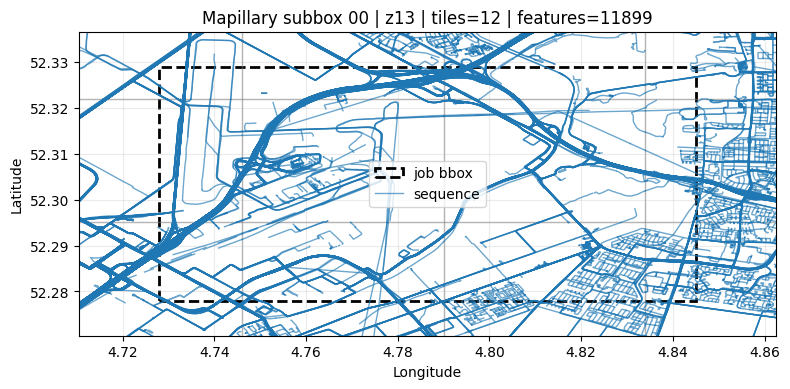

In [122]:
import os
import re
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def mapillary_read_csv_rows(path: Path) -> list[dict]:
    if not path.exists():
        return []
    with path.open('r', newline='', encoding='utf-8') as handle:
        return list(csv.DictReader(handle))


def mapillary_parse_point_wkt(wkt: str) -> tuple[float, float] | None:
    if not wkt:
        return None
    wkt = wkt.strip()
    if not wkt.startswith('POINT'):
        return None
    body = wkt[len('POINT'):].strip()
    if not (body.startswith('(') and body.endswith(')')):
        return None
    lon, lat = body[1:-1].strip().split()
    return float(lon), float(lat)


def mapillary_parse_linestring_wkt(wkt: str) -> list[list[tuple[float, float]]]:
    if not wkt:
        return []

    wkt = wkt.strip()
    if wkt.startswith('MULTILINESTRING'):
        body = wkt[len('MULTILINESTRING'):].strip()
        if not (body.startswith('(') and body.endswith(')')):
            return []
        inner = body[1:-1].strip()
        if not inner:
            return []
        raw_segments = re.split(r'\)\s*,\s*\(', inner[1:-1])
    elif wkt.startswith('LINESTRING'):
        body = wkt[len('LINESTRING'):].strip()
        if not (body.startswith('(') and body.endswith(')')):
            return []
        raw_segments = [body[1:-1]]
    else:
        return []

    segments = []
    for raw_segment in raw_segments:
        coords = []
        for pair in raw_segment.split(','):
            lon, lat = pair.strip().split()
            coords.append((float(lon), float(lat)))
        if coords:
            segments.append(coords)
    return segments


def mapillary_layer_style(layer_name: str) -> tuple[str, float]:
    palette = {
        'sequence': ('#1F78B4', 1.0),
        'image': ('#E31A1C', 0.8),
        'overview': ('#33A02C', 0.7),
        'map_feature': ('#6A3D9A', 0.9),
        'traffic_sign': ('#FF7F00', 0.9),
        'computed_sequence': ('#1F78B4', 0.9),
        'computed_image': ('#E31A1C', 0.7),
        'computed_overview': ('#33A02C', 0.6),
    }
    return palette.get(layer_name, ('#4D4D4D', 0.8))


def plot_mapillary_result(result: dict, figsize: tuple[int, int] = (9, 9), show_tile_labels: bool = False) -> None:
    tile_rows = mapillary_read_csv_rows(Path(result['tile_summary_path']))
    feature_rows = mapillary_read_csv_rows(Path(result['feature_records_path']))
    bbox = result['job']['bbox']

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(
        f"Mapillary subbox {result['job']['index']:02d} | z{result['job']['source_zoom']} | "
        f"tiles={len(tile_rows)} | features={len(feature_rows)}"
    )

    bbox_width = bbox['max_lon'] - bbox['min_lon']
    bbox_height = bbox['max_lat'] - bbox['min_lat']
    ax.add_patch(
        Rectangle(
            (bbox['min_lon'], bbox['min_lat']),
            bbox_width,
            bbox_height,
            fill=False,
            edgecolor='black',
            linewidth=2.0,
            linestyle='--',
            label='job bbox',
        )
    )

    for row in tile_rows:
        x = int(row['x'])
        y = int(row['y'])
        z = int(row['source_zoom'])
        lon_min, lat_min, lon_max, lat_max = tile_to_lonlat_bounds(x, y, z)
        ax.add_patch(
            Rectangle(
                (lon_min, lat_min),
                lon_max - lon_min,
                lat_max - lat_min,
                fill=False,
                edgecolor='#7F7F7F',
                linewidth=1.0,
                alpha=0.35,
            )
        )
        if show_tile_labels:
            ax.text(
                (lon_min + lon_max) / 2,
                (lat_min + lat_max) / 2,
                f"{x},{y}",
                fontsize=7,
                ha='center',
                va='center',
                color='#666666',
            )

    seen_labels = set()
    point_groups = {}

    for row in feature_rows:
        layer_name = row.get('layer_name', 'unknown')
        geometry_type = row.get('geometry_type', '')
        color, width = mapillary_layer_style(layer_name)

        if geometry_type in ('LineString', 'MultiLineString'):
            label = None
            if layer_name not in seen_labels:
                label = layer_name
                seen_labels.add(layer_name)
            for segment in mapillary_parse_linestring_wkt(row.get('geometry_wkt', '')):
                lons = [point[0] for point in segment]
                lats = [point[1] for point in segment]
                ax.plot(lons, lats, color=color, linewidth=width, alpha=0.65, label=label)
                label = None
        elif geometry_type in ('Point', 'MultiPoint'):
            point = mapillary_parse_point_wkt(row.get('geometry_wkt', ''))
            if point is not None:
                point_groups.setdefault(layer_name, []).append(point)

    for layer_name, points in point_groups.items():
        color, _ = mapillary_layer_style(layer_name)
        xs = [point[0] for point in points]
        ys = [point[1] for point in points]
        ax.scatter(xs, ys, s=10, c=color, alpha=0.7, label=layer_name if layer_name not in seen_labels else None)
        seen_labels.add(layer_name)

    pad_lon = max(bbox_width * 0.15, 0.002)
    pad_lat = max(bbox_height * 0.15, 0.002)
    ax.set_xlim(bbox['min_lon'] - pad_lon, bbox['max_lon'] + pad_lon)
    ax.set_ylim(bbox['min_lat'] - pad_lat, bbox['max_lat'] + pad_lat)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(alpha=0.25)
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='best')
    plt.show()


def plot_all_mapillary_results(results_to_plot: list[dict], show_tile_labels: bool = False) -> None:
    if not results_to_plot:
        print('No Mapillary results available to visualize.')
        return
    for result in results_to_plot:
        plot_mapillary_result(result, show_tile_labels=show_tile_labels)


plot_all_mapillary_results(mapillary_results)


## Baidu Street View Raster Tiles

Fetch Baidu street-view coverage raster tiles and visualize the resulting tile mosaic and coverage mask.


### Configuration


In [123]:
BAIDU_OUTPUT_NAMESPACE = 'baidu_mapsv_raster'
BAIDU_SOURCE_ID = 'baidu_mapsv_tile'

BAIDU_AREA_PRESETS = {
    'hong_kong_urban_bbox_approx': {
        'min_lon': 113.87,
        'min_lat': 22.19,
        'max_lon': 114.33,
        'max_lat': 22.45,
    },
}

BAIDU_BBOX = dict(BAIDU_AREA_PRESETS['hong_kong_urban_bbox_approx'])
BAIDU_DISPLAY_ZOOM = 13
BAIDU_URL_TEMPLATE = 'https://mapsv0.bdimg.com/tile/?udt=20200825&qt=tile&styles=pl&x={x}&y={y}&z={z}'
BAIDU_REQUEST_HEADERS = {
    'User-Agent': 'global-svi-coverage-observatory-notebook/0.2',
    'Referer': 'https://map.baidu.com/',
}
BAIDU_RUN_LABEL = 'hong_kong_baidu_raster'
BAIDU_REQUEST_TIMEOUT_SECONDS = 60
BAIDU_DRY_RUN = False

print('BAIDU_BBOX:', BAIDU_BBOX)
print('BAIDU_DISPLAY_ZOOM:', BAIDU_DISPLAY_ZOOM)


BAIDU_BBOX: {'min_lon': 113.87, 'min_lat': 22.19, 'max_lon': 114.33, 'max_lat': 22.45}
BAIDU_DISPLAY_ZOOM: 13


### Baidu Coordinate Helpers


In [124]:
BAIDU_LLBAND = [75, 60, 45, 30, 15, 0]
BAIDU_LL2MC = [
    [-0.0015702102444, 111320.7020616939, 1704480524535203, -10338987376042340, 26112667856603880, -35149669176653700, 26595700718403920, -10725012454188240, 1800819912950474, 82.5],
    [0.0008277824516172526, 111320.7020463578, 647795574.6671607, -4082003173.641316, 10774905663.51142, -15171875531.51559, 12053065338.62167, -5124939663.577472, 913311935.9512032, 67.5],
    [0.00337398766765, 111320.7020202162, 4481351.045890365, -23393751.19931662, 79682215.47186455, -115964993.2797253, 97236711.15602145, -43661946.33752821, 8477230.501135234, 52.5],
    [0.00220636496208, 111320.7020209128, 51751.86112841131, 3796837.749470245, 992013.7397791013, -1221952.21711287, 1340652.697009075, -620943.6990984312, 144416.9293806241, 37.5],
    [-0.0003441963504368392, 111320.7020576856, 278.2353980772752, 2485758.690035394, 6070.750963243378, 54821.18345352118, 9540.606633304236, -2710.55326746645, 1405.483844121726, 22.5],
    [-0.0003218135878613132, 111320.7020701615, 0.00369383431289, 823725.6402795718, 0.46104986909093, 2351.343141331292, 1.58060784298199, 8.77738589078284, 0.37238884252424, 7.45],
]


def baidu_out_of_china(lon: float, lat: float) -> bool:
    return not (72.004 <= lon <= 137.8347 and 0.8293 <= lat <= 55.8271)


def baidu_transform_lat(lon: float, lat: float) -> float:
    ret = -100.0 + 2.0 * lon + 3.0 * lat + 0.2 * lat * lat + 0.1 * lon * lat + 0.2 * math.sqrt(abs(lon))
    ret += (20.0 * math.sin(6.0 * lon * math.pi) + 20.0 * math.sin(2.0 * lon * math.pi)) * 2.0 / 3.0
    ret += (20.0 * math.sin(lat * math.pi) + 40.0 * math.sin(lat / 3.0 * math.pi)) * 2.0 / 3.0
    ret += (160.0 * math.sin(lat / 12.0 * math.pi) + 320 * math.sin(lat * math.pi / 30.0)) * 2.0 / 3.0
    return ret


def baidu_transform_lon(lon: float, lat: float) -> float:
    ret = 300.0 + lon + 2.0 * lat + 0.1 * lon * lon + 0.1 * lon * lat + 0.1 * math.sqrt(abs(lon))
    ret += (20.0 * math.sin(6.0 * lon * math.pi) + 20.0 * math.sin(2.0 * lon * math.pi)) * 2.0 / 3.0
    ret += (20.0 * math.sin(lon * math.pi) + 40.0 * math.sin(lon / 3.0 * math.pi)) * 2.0 / 3.0
    ret += (150.0 * math.sin(lon / 12.0 * math.pi) + 300.0 * math.sin(lon / 30.0 * math.pi)) * 2.0 / 3.0
    return ret


def wgs84_to_gcj02(lon: float, lat: float) -> tuple[float, float]:
    if baidu_out_of_china(lon, lat):
        return lon, lat

    a = 6378245.0
    ee = 0.00669342162296594323
    dlat = baidu_transform_lat(lon - 105.0, lat - 35.0)
    dlon = baidu_transform_lon(lon - 105.0, lat - 35.0)
    radlat = lat / 180.0 * math.pi
    magic = math.sin(radlat)
    magic = 1 - ee * magic * magic
    sqrtmagic = math.sqrt(magic)
    dlat = (dlat * 180.0) / ((a * (1 - ee)) / (magic * sqrtmagic) * math.pi)
    dlon = (dlon * 180.0) / (a / sqrtmagic * math.cos(radlat) * math.pi)
    return lon + dlon, lat + dlat


def gcj02_to_bd09(lon: float, lat: float) -> tuple[float, float]:
    z = math.sqrt(lon * lon + lat * lat) + 0.00002 * math.sin(lat * math.pi * 3000.0 / 180.0)
    theta = math.atan2(lat, lon) + 0.000003 * math.cos(lon * math.pi * 3000.0 / 180.0)
    return z * math.cos(theta) + 0.0065, z * math.sin(theta) + 0.006


def baidu_get_range(value: float, minimum: float, maximum: float) -> float:
    return min(max(value, minimum), maximum)


def baidu_get_loop(value: float, minimum: float, maximum: float) -> float:
    while value > maximum:
        value -= maximum - minimum
    while value < minimum:
        value += maximum - minimum
    return value


def baidu_convertor(x: float, y: float, coeffs: list[float]) -> tuple[float, float]:
    x_temp = coeffs[0] + coeffs[1] * abs(x)
    cc = abs(y) / coeffs[9]
    y_temp = coeffs[2] + coeffs[3] * cc + coeffs[4] * cc**2 + coeffs[5] * cc**3 + coeffs[6] * cc**4 + coeffs[7] * cc**5 + coeffs[8] * cc**6
    x_temp *= -1 if x < 0 else 1
    y_temp *= -1 if y < 0 else 1
    return x_temp, y_temp


def bd09ll_to_bd09mc(lon: float, lat: float) -> tuple[float, float]:
    lon = baidu_get_loop(lon, -180, 180)
    lat = baidu_get_range(lat, -74, 74)

    coeffs = None
    for index, band in enumerate(BAIDU_LLBAND):
        if lat >= band:
            coeffs = BAIDU_LL2MC[index]
            break

    if coeffs is None:
        for index in range(len(BAIDU_LLBAND) - 1, -1, -1):
            if lat <= -BAIDU_LLBAND[index]:
                coeffs = BAIDU_LL2MC[index]
                break

    if coeffs is None:
        raise ValueError(f'Could not choose BAIDU_LL2MC coeffs for lon/lat: {(lon, lat)}')

    return baidu_convertor(lon, lat, coeffs)


def wgs84_to_baidu_tile(lon: float, lat: float, zoom: int) -> tuple[int, int]:
    gcj_lon, gcj_lat = wgs84_to_gcj02(lon, lat)
    bd_lon, bd_lat = gcj02_to_bd09(gcj_lon, gcj_lat)
    mc_x, mc_y = bd09ll_to_bd09mc(bd_lon, bd_lat)
    tile_span = 256 * (2 ** (18 - zoom))
    tile_x = int(math.floor(mc_x / tile_span))
    tile_y = int(math.floor(mc_y / tile_span))
    return tile_x, tile_y


def baidu_bbox_to_tile_range(bbox: dict[str, float], zoom: int) -> dict[str, int]:
    corner_tiles = [
        wgs84_to_baidu_tile(bbox['min_lon'], bbox['min_lat'], zoom),
        wgs84_to_baidu_tile(bbox['min_lon'], bbox['max_lat'], zoom),
        wgs84_to_baidu_tile(bbox['max_lon'], bbox['min_lat'], zoom),
        wgs84_to_baidu_tile(bbox['max_lon'], bbox['max_lat'], zoom),
    ]
    xs = [tile[0] for tile in corner_tiles]
    ys = [tile[1] for tile in corner_tiles]
    return {
        'x_min': min(xs),
        'x_max': max(xs),
        'y_min': min(ys),
        'y_max': max(ys),
    }


### Fetch Tiles


In [125]:
BAIDU_TILE_SUMMARY_FIELDS = [
    'provider',
    'source_id',
    'display_zoom',
    'source_zoom',
    'x',
    'y',
    'tile_url',
    'content_type',
    'width',
    'height',
    'coverage_pixel_count',
    'total_pixel_count',
    'coverage_ratio',
    'sha256',
    'byte_length',
    'output_path',
    'metadata_path',
    'fetched_at',
]


baidu_tile_range = baidu_bbox_to_tile_range(BAIDU_BBOX, BAIDU_DISPLAY_ZOOM)
baidu_job = {
    'index': 0,
    'bbox': BAIDU_BBOX,
    'display_zoom': BAIDU_DISPLAY_ZOOM,
    'source_zoom': BAIDU_DISPLAY_ZOOM,
    'source_tile_range': baidu_tile_range,
    'source_tile_count': tile_count(baidu_tile_range),
    'run_label': BAIDU_RUN_LABEL,
}

print('Baidu tile range:', baidu_tile_range)
print('Baidu tile count:', baidu_job['source_tile_count'])


def fetch_baidu_tile(url: str, headers: dict[str, str], timeout_seconds: int) -> tuple[bytes, str]:
    response = requests.get(url, headers=headers, timeout=timeout_seconds)
    response.raise_for_status()
    return response.content, response.headers.get('Content-Type', '')


def fetch_baidu_raster_job(
    job: dict,
    template: str,
    headers: dict[str, str],
    timeout_seconds: int,
    output_root: Path,
    output_namespace: str,
) -> dict:
    output_dir = output_root / output_namespace / job['run_label']
    ensure_directory(output_dir)

    fetched_tiles = []
    skipped_tiles = []
    error_tiles = []

    for x, y in iter_tile_coords(job['source_tile_range']):
        tile_url = template.format(x=x, y=y, z=job['source_zoom'])
        fetched_at = utc_now_iso()

        try:
            payload, content_type = fetch_baidu_tile(tile_url, headers, timeout_seconds)
            png_summary = summarize_png(payload)
        except Exception as exc:
            error_tiles.append({
                'provider': output_namespace,
                'source_id': BAIDU_SOURCE_ID,
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'reason': repr(exc),
            })
            continue

        if not content_type.startswith('image/png'):
            skipped_tiles.append({
                'provider': output_namespace,
                'source_id': BAIDU_SOURCE_ID,
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'content_type': content_type,
            })
            continue

        tile_path = output_dir / 'tiles' / str(job['source_zoom']) / str(x) / f'{y}.png'
        ensure_directory(tile_path.parent)
        tile_path.write_bytes(payload)

        metadata_path = Path(str(tile_path) + '.metadata.json')
        row = {
            'provider': output_namespace,
            'source_id': BAIDU_SOURCE_ID,
            'display_zoom': job['display_zoom'],
            'source_zoom': job['source_zoom'],
            'x': x,
            'y': y,
            'tile_url': tile_url,
            'content_type': content_type,
            'width': png_summary['width'],
            'height': png_summary['height'],
            'coverage_pixel_count': png_summary['coverage_pixel_count'],
            'total_pixel_count': png_summary['total_pixel_count'],
            'coverage_ratio': png_summary['coverage_ratio'],
            'sha256': sha256_bytes(payload),
            'byte_length': len(payload),
            'output_path': str(tile_path),
            'metadata_path': str(metadata_path),
            'fetched_at': fetched_at,
        }
        metadata_path.write_text(json.dumps(row, indent=2, sort_keys=True), encoding='utf-8')
        fetched_tiles.append(row)

    tile_summary_path = output_dir / 'tile_summary.csv'
    write_csv(tile_summary_path, fetched_tiles, BAIDU_TILE_SUMMARY_FIELDS)

    manifest = {
        'provider': output_namespace,
        'source_id': BAIDU_SOURCE_ID,
        'template': template,
        'request_headers': headers,
        'bbox': job['bbox'],
        'display_zoom': job['display_zoom'],
        'source_zoom': job['source_zoom'],
        'source_tile_range': job['source_tile_range'],
        'source_tile_count': job['source_tile_count'],
        'fetched_tile_count': len(fetched_tiles),
        'skipped_tile_count': len(skipped_tiles),
        'error_tile_count': len(error_tiles),
        'tile_summary_path': str(tile_summary_path),
        'fetched_at': utc_now_iso(),
    }
    manifest_path = output_dir / 'manifest.json'
    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding='utf-8')

    if skipped_tiles:
        (output_dir / 'skipped_tiles.json').write_text(
            json.dumps(skipped_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )
    if error_tiles:
        (output_dir / 'errors.json').write_text(
            json.dumps(error_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )

    return {
        'output_dir': output_dir,
        'tile_summary_path': tile_summary_path,
        'manifest_path': manifest_path,
        'manifest': manifest,
        'fetched_tiles': fetched_tiles,
        'skipped_tiles': skipped_tiles,
        'error_tiles': error_tiles,
        'job': job,
    }


baidu_results = []

if BAIDU_DRY_RUN:
    print('BAIDU_DRY_RUN is True. No requests sent.')
else:
    baidu_result = fetch_baidu_raster_job(
        job=baidu_job,
        template=BAIDU_URL_TEMPLATE,
        headers=BAIDU_REQUEST_HEADERS,
        timeout_seconds=BAIDU_REQUEST_TIMEOUT_SECONDS,
        output_root=OUTPUT_ROOT,
        output_namespace=BAIDU_OUTPUT_NAMESPACE,
    )
    baidu_results.append(baidu_result)
    print('Saved to:', baidu_result['output_dir'])
    print('Fetched tiles:', baidu_result['manifest']['fetched_tile_count'])
    print('Skipped tiles:', baidu_result['manifest']['skipped_tile_count'])
    print('Errors:', baidu_result['manifest']['error_tile_count'])


Baidu tile range: {'x_min': 1547, 'x_max': 1553, 'y_min': 307, 'y_max': 311}
Baidu tile count: 35


Saved to: /data/zicheng/2026_global_street_view_coverage/data/raw/baidu_mapsv_raster/hong_kong_baidu_raster
Fetched tiles: 0
Skipped tiles: 0
Errors: 35


### Visualize Results


In [126]:
import matplotlib.pyplot as plt

def baidu_load_rgba_image(path: str) -> np.ndarray:
    with Image.open(path) as image:
        return np.array(image.convert('RGBA'))


def baidu_mask_rgba_from_image(rgba: np.ndarray) -> np.ndarray:
    mask = np.zeros_like(rgba)
    alpha = rgba[:, :, 3] > 0
    mask[alpha] = np.array([27, 94, 255, 190], dtype=np.uint8)
    return mask


def build_tile_mosaic(tile_rows: list[dict]) -> tuple[np.ndarray, dict[str, int]]:
    if not tile_rows:
        raise ValueError('No tile rows available for mosaic assembly.')

    x_values = sorted({int(row['x']) for row in tile_rows})
    y_values = sorted({int(row['y']) for row in tile_rows})
    x_min, x_max = x_values[0], x_values[-1]
    y_min, y_max = y_values[0], y_values[-1]

    sample = baidu_load_rgba_image(tile_rows[0]['output_path'])
    tile_height, tile_width = sample.shape[0], sample.shape[1]
    mosaic = np.zeros(((y_max - y_min + 1) * tile_height, (x_max - x_min + 1) * tile_width, 4), dtype=np.uint8)

    for row in tile_rows:
        x = int(row['x'])
        y = int(row['y'])
        rgba = baidu_load_rgba_image(row['output_path'])
        row_index = y_max - y
        col_index = x - x_min
        top = row_index * tile_height
        left = col_index * tile_width
        mosaic[top:top + tile_height, left:left + tile_width] = rgba

    info = {
        'x_min': x_min,
        'x_max': x_max,
        'y_min': y_min,
        'y_max': y_max,
        'tile_width': tile_width,
        'tile_height': tile_height,
    }
    return mosaic, info


def plot_baidu_raster_result(result: dict, figsize: tuple[int, int] = (14, 7), show_tile_labels: bool = True) -> None:
    tile_rows = read_csv_rows(Path(result['tile_summary_path']))
    if not tile_rows:
        print('No fetched Baidu tiles found for visualization:', result['tile_summary_path'])
        return

    raw_mosaic, info = build_tile_mosaic(tile_rows)
    mask_mosaic = baidu_mask_rgba_from_image(raw_mosaic)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    ax_raw, ax_mask = axes
    ax_raw.imshow(raw_mosaic)
    ax_mask.imshow(mask_mosaic)

    title = (
        f"Hong Kong | z{result['job']['source_zoom']} | "
        f"x={info['x_min']}..{info['x_max']} | y={info['y_min']}..{info['y_max']} | "
        f"tiles={len(tile_rows)}"
    )
    ax_raw.set_title(title + ' | raster mosaic')
    ax_mask.set_title(title + ' | coverage mask')

    cols = info['x_max'] - info['x_min'] + 1
    rows = info['y_max'] - info['y_min'] + 1
    tile_width = info['tile_width']
    tile_height = info['tile_height']

    for ax in axes:
        for col in range(cols + 1):
            ax.axvline(col * tile_width - 0.5, color='#333333', linewidth=0.6, alpha=0.5)
        for row in range(rows + 1):
            ax.axhline(row * tile_height - 0.5, color='#333333', linewidth=0.6, alpha=0.5)

        if show_tile_labels:
            ax.set_xticks([(col + 0.5) * tile_width for col in range(cols)])
            ax.set_xticklabels([str(info['x_min'] + col) for col in range(cols)], rotation=45, ha='right')
            ax.set_yticks([(row + 0.5) * tile_height for row in range(rows)])
            ax.set_yticklabels([str(info['y_max'] - row) for row in range(rows)])
            ax.set_xlabel('Baidu tile x')
            ax.set_ylabel('Baidu tile y')
        else:
            ax.set_xticks([])
            ax.set_yticks([])

    total_coverage_pixels = sum(int(row['coverage_pixel_count']) for row in tile_rows)
    total_pixels = sum(int(row['total_pixel_count']) for row in tile_rows)
    coverage_ratio = total_coverage_pixels / total_pixels if total_pixels else 0.0
    fig.suptitle(f'Coverage pixel ratio across fetched Baidu tiles: {coverage_ratio:.4f}')
    plt.tight_layout()
    plt.show()


def plot_all_baidu_results(results_to_plot: list[dict], show_tile_labels: bool = True) -> None:
    if not results_to_plot:
        print('No Baidu results available to visualize.')
        return
    for result in results_to_plot:
        plot_baidu_raster_result(result, show_tile_labels=show_tile_labels)


plot_all_baidu_results(baidu_results)


No fetched Baidu tiles found for visualization: /data/zicheng/2026_global_street_view_coverage/data/raw/baidu_mapsv_raster/hong_kong_baidu_raster/tile_summary.csv


## Yandex Street-View Raster Tiles

Fetch Yandex `stv` raster coverage tiles from the frontend renderer. This section uses Yandex's WGS84 elliptic Mercator tile grid for both tile selection and visualization bounds.


### Configuration and Yandex Elliptic Mercator Helpers


In [127]:
YANDEX_RASTER_OUTPUT_NAMESPACE = 'yandex_stv_raster'
YANDEX_RASTER_SOURCE_ID = 'yandex_stv_tiles_png'
YANDEX_RASTER_TILE_GRID_PROJECTION = 'yandex_wgs84_mercator'
YANDEX_WGS84_MERCATOR_ECCENTRICITY = 0.0818191908426
YANDEX_WGS84_MERCATOR_LAT_LIMIT = 85.08405905


def yandex_clamp_lat(lat: float) -> float:
    return max(min(lat, YANDEX_WGS84_MERCATOR_LAT_LIMIT), -YANDEX_WGS84_MERCATOR_LAT_LIMIT)


def yandex_elliptic_mercator_lat_to_y_fraction(lat: float) -> float:
    lat_rad = math.radians(yandex_clamp_lat(lat))
    eccentricity = YANDEX_WGS84_MERCATOR_ECCENTRICITY
    sin_lat = math.sin(lat_rad)
    mercator_y = math.log(
        math.tan(math.pi / 4.0 + lat_rad / 2.0)
        * ((1.0 - eccentricity * sin_lat) / (1.0 + eccentricity * sin_lat)) ** (eccentricity / 2.0)
    )
    return (1.0 - mercator_y / math.pi) / 2.0


def yandex_lonlat_to_tile(lon: float, lat: float, zoom: int) -> tuple[int, int]:
    scale = 2 ** zoom
    x = math.floor((lon + 180.0) / 360.0 * scale)
    y = math.floor(yandex_elliptic_mercator_lat_to_y_fraction(lat) * scale)
    return int(x), int(y)


def yandex_bbox_to_tile_range(bbox: dict[str, float], zoom: int) -> dict[str, int]:
    x1, y2 = yandex_lonlat_to_tile(bbox['min_lon'], bbox['min_lat'], zoom)
    x2, y1 = yandex_lonlat_to_tile(bbox['max_lon'], bbox['max_lat'], zoom)
    return {
        'x_min': min(x1, x2),
        'x_max': max(x1, x2),
        'y_min': min(y1, y2),
        'y_max': max(y1, y2),
    }


def yandex_elliptic_mercator_y_fraction_to_lat(y_fraction: float, iterations: int = 12) -> float:
    mercator_y = math.pi * (1.0 - 2.0 * y_fraction)
    eccentricity = YANDEX_WGS84_MERCATOR_ECCENTRICITY
    lat_rad = 2.0 * math.atan(math.exp(mercator_y)) - math.pi / 2.0

    for _ in range(iterations):
        sin_lat = math.sin(lat_rad)
        correction = ((1.0 + eccentricity * sin_lat) / (1.0 - eccentricity * sin_lat)) ** (eccentricity / 2.0)
        lat_rad = 2.0 * math.atan(math.exp(mercator_y) * correction) - math.pi / 2.0

    return math.degrees(lat_rad)


def yandex_tile_to_lonlat_bounds(x: int, y: int, zoom: int) -> tuple[float, float, float, float]:
    scale = 2 ** zoom
    lon_min = x / scale * 360.0 - 180.0
    lon_max = (x + 1) / scale * 360.0 - 180.0
    lat_max = yandex_elliptic_mercator_y_fraction_to_lat(y / scale)
    lat_min = yandex_elliptic_mercator_y_fraction_to_lat((y + 1) / scale)
    return lon_min, lat_min, lon_max, lat_max


YANDEX_RASTER_AREA_PRESETS = {
    'abakan_bbox': {
        'min_lon': 91.54,
        'min_lat': 53.66,
        'max_lon': 91.72,
        'max_lat': 53.79,
    },
    'moscow_center_stv_bbox': {
        'min_lon': 37.53,
        'min_lat': 55.73,
        'max_lon': 37.60,
        'max_lat': 55.76,
    },
}

YANDEX_RASTER_BBOX = dict(YANDEX_RASTER_AREA_PRESETS['moscow_center_stv_bbox'])
YANDEX_RASTER_DISPLAY_ZOOM = 13
YANDEX_RASTER_REQUEST_LAYER = 'stv'
YANDEX_RASTER_FRONTEND_PAGE_URL = (
    'https://yandex.com/maps/213/moscow/?l=stv&ll=37.565000%2C55.745000&z=13'
)
YANDEX_RASTER_REQUEST_HEADERS = {
    'User-Agent': 'global-svi-coverage-observatory-notebook/0.2',
    'Accept': 'image/png, image/*;q=0.9, */*;q=0.1',
    'Referer': 'https://yandex.com/maps/',
}
YANDEX_RASTER_VERSION_FALLBACK = '2026.05.19.17.14-1_26.05.18-0-29389'
YANDEX_RASTER_RUN_LABEL = 'moscow_center_yandex_stv_raster_z13'
YANDEX_RASTER_REQUEST_TIMEOUT_SECONDS = 60
YANDEX_RASTER_DRY_RUN = False
YANDEX_RASTER_BASEMAP_ENABLED = True
YANDEX_RASTER_BASEMAP_ZOOM = 15


yandex_raster_tile_range = yandex_bbox_to_tile_range(YANDEX_RASTER_BBOX, YANDEX_RASTER_DISPLAY_ZOOM)
yandex_raster_job = {
    'index': 0,
    'bbox': YANDEX_RASTER_BBOX,
    'display_zoom': YANDEX_RASTER_DISPLAY_ZOOM,
    'source_zoom': YANDEX_RASTER_DISPLAY_ZOOM,
    'source_tile_range': yandex_raster_tile_range,
    'source_tile_count': tile_count(yandex_raster_tile_range),
    'tile_grid_projection': YANDEX_RASTER_TILE_GRID_PROJECTION,
    'run_label': YANDEX_RASTER_RUN_LABEL,
}

print('YANDEX_RASTER_BBOX:', YANDEX_RASTER_BBOX)
print('YANDEX_RASTER_DISPLAY_ZOOM:', YANDEX_RASTER_DISPLAY_ZOOM)
print('YANDEX_RASTER_REQUEST_LAYER:', YANDEX_RASTER_REQUEST_LAYER)
print('YANDEX_RASTER_TILE_GRID_PROJECTION:', YANDEX_RASTER_TILE_GRID_PROJECTION)
print('YANDEX_RASTER_TILE_RANGE:', yandex_raster_tile_range)
print('YANDEX_RASTER_TILE_COUNT:', yandex_raster_job['source_tile_count'])
print('YANDEX_RASTER_DRY_RUN:', YANDEX_RASTER_DRY_RUN)


YANDEX_RASTER_BBOX: {'min_lon': 37.53, 'min_lat': 55.73, 'max_lon': 37.6, 'max_lat': 55.76}
YANDEX_RASTER_DISPLAY_ZOOM: 13
YANDEX_RASTER_REQUEST_LAYER: stv
YANDEX_RASTER_TILE_GRID_PROJECTION: yandex_wgs84_mercator
YANDEX_RASTER_TILE_RANGE: {'x_min': 4950, 'x_max': 4951, 'y_min': 2567, 'y_max': 2569}
YANDEX_RASTER_TILE_COUNT: 6
YANDEX_RASTER_DRY_RUN: False


### Fetch Tiles


In [128]:
YANDEX_RASTER_TILE_SUMMARY_FIELDS = [
    'provider',
    'source_id',
    'display_zoom',
    'source_zoom',
    'x',
    'y',
    'tile_url',
    'http_status',
    'content_type',
    'is_empty',
    'width',
    'height',
    'coverage_pixel_count',
    'total_pixel_count',
    'coverage_ratio',
    'sha256',
    'byte_length',
    'output_path',
    'metadata_path',
    'fetched_at',
]


def yandex_raster_discover_frontend_config(page_url: str, headers: dict[str, str], timeout_seconds: int) -> dict[str, str]:
    response = requests.get(page_url, headers=headers, timeout=timeout_seconds)
    response.raise_for_status()
    match = re.search(
        r'<script type="application/json" class="state-view">(.*?)</script>',
        response.text,
        re.S,
    )
    if not match:
        raise RuntimeError('Could not locate Yandex state-view JSON in the frontend page.')

    state = json.loads(match.group(1))
    config = state['config']
    return {
        'stv_tiles_template': config['hosts']['stvTiles'],
        'stv_version': config['layers']['stv']['version'],
        'query_layers': state.get('query', {}).get('l', ''),
    }


def yandex_raster_normalize_tile_template(template: str, request_layer: str) -> str:
    normalized = template.replace('\u0026', '&')
    normalized = normalized.replace('l=stv&', f'l={request_layer}&')
    normalized = normalized.replace('https://0%d.core-stv-renderer.maps.yandex.net/', 'https://core-stv-renderer.maps.yandex.net/')
    normalized = normalized.replace('%c', 'x={x}&y={y}&z={z}')
    normalized = normalized.replace('%v', '{version}')
    normalized = normalized.replace('%l', 'lang=en_US&scale=1')
    return normalized


def yandex_raster_fetch_tile(url: str, headers: dict[str, str], timeout_seconds: int):
    response = requests.get(url, headers=headers, timeout=timeout_seconds)
    if response.status_code == 204:
        return b'', response.status_code, response.headers.get('Content-Type', '')
    response.raise_for_status()
    return response.content, response.status_code, response.headers.get('Content-Type', '')


def fetch_yandex_raster_job(
    job: dict,
    page_url: str,
    headers: dict[str, str],
    timeout_seconds: int,
    output_root: Path,
    output_namespace: str,
    version_fallback: str,
    request_layer: str,
) -> dict:
    output_dir = output_root / output_namespace / job['run_label']
    ensure_directory(output_dir)

    frontend_config = {
        'stv_tiles_template': 'https://core-stv-renderer.maps.yandex.net/2.x/tiles?l=stv&x={x}&y={y}&z={z}&scale=1&v={version}&lang=en_US&format=png',
        'stv_version': version_fallback,
        'query_layers': '',
        'config_source': 'fallback',
    }
    try:
        discovered = yandex_raster_discover_frontend_config(page_url, headers, timeout_seconds)
        frontend_config.update(discovered)
        frontend_config['config_source'] = 'live_page'
    except Exception as exc:
        frontend_config['config_error'] = repr(exc)

    tile_template = yandex_raster_normalize_tile_template(frontend_config['stv_tiles_template'], request_layer)

    tile_rows = []
    error_tiles = []
    nonempty_tile_count = 0
    empty_tile_count = 0

    for x, y in iter_tile_coords(job['source_tile_range']):
        tile_url = tile_template.format(x=x, y=y, z=job['source_zoom'], version=frontend_config['stv_version'])
        fetched_at = utc_now_iso()
        metadata_path = output_dir / 'tiles' / str(job['source_zoom']) / str(x) / f'{y}.png.metadata.json'
        row = {
            'provider': output_namespace,
            'source_id': YANDEX_RASTER_SOURCE_ID,
            'display_zoom': job['display_zoom'],
            'source_zoom': job['source_zoom'],
            'x': x,
            'y': y,
            'tile_url': tile_url,
            'http_status': '',
            'content_type': '',
            'is_empty': '',
            'width': '',
            'height': '',
            'coverage_pixel_count': '',
            'total_pixel_count': '',
            'coverage_ratio': '',
            'sha256': '',
            'byte_length': '',
            'output_path': '',
            'metadata_path': str(metadata_path),
            'fetched_at': fetched_at,
        }

        try:
            payload, http_status, content_type = yandex_raster_fetch_tile(tile_url, headers, timeout_seconds)
            row['http_status'] = http_status
            row['content_type'] = content_type
        except Exception as exc:
            error_tiles.append({
                'provider': output_namespace,
                'source_id': YANDEX_RASTER_SOURCE_ID,
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'reason': repr(exc),
            })
            tile_rows.append(row)
            continue

        if http_status == 204 or not payload:
            row['is_empty'] = True
            empty_tile_count += 1
            ensure_directory(metadata_path.parent)
            metadata_path.write_text(json.dumps(row, indent=2, sort_keys=True), encoding='utf-8')
            tile_rows.append(row)
            continue

        if not content_type.startswith('image/png'):
            error_tiles.append({
                'provider': output_namespace,
                'source_id': YANDEX_RASTER_SOURCE_ID,
                'display_zoom': job['display_zoom'],
                'source_zoom': job['source_zoom'],
                'x': x,
                'y': y,
                'tile_url': tile_url,
                'fetched_at': fetched_at,
                'reason': f'Unexpected content type: {content_type}',
            })
            tile_rows.append(row)
            continue

        png_summary = summarize_png(payload)
        if png_summary['coverage_pixel_count'] == 0:
            row.update({
                'is_empty': True,
                'width': png_summary['width'],
                'height': png_summary['height'],
                'coverage_pixel_count': png_summary['coverage_pixel_count'],
                'total_pixel_count': png_summary['total_pixel_count'],
                'coverage_ratio': png_summary['coverage_ratio'],
                'sha256': sha256_bytes(payload),
                'byte_length': len(payload),
            })
            empty_tile_count += 1
            ensure_directory(metadata_path.parent)
            metadata_path.write_text(json.dumps(row, indent=2, sort_keys=True), encoding='utf-8')
            tile_rows.append(row)
            continue

        tile_path = output_dir / 'tiles' / str(job['source_zoom']) / str(x) / f'{y}.png'
        ensure_directory(tile_path.parent)
        tile_path.write_bytes(payload)

        row.update({
            'is_empty': False,
            'width': png_summary['width'],
            'height': png_summary['height'],
            'coverage_pixel_count': png_summary['coverage_pixel_count'],
            'total_pixel_count': png_summary['total_pixel_count'],
            'coverage_ratio': png_summary['coverage_ratio'],
            'sha256': sha256_bytes(payload),
            'byte_length': len(payload),
            'output_path': str(tile_path),
        })
        metadata_path.write_text(json.dumps(row, indent=2, sort_keys=True), encoding='utf-8')
        tile_rows.append(row)
        nonempty_tile_count += 1

    tile_summary_path = output_dir / 'tile_summary.csv'
    write_csv(tile_summary_path, tile_rows, YANDEX_RASTER_TILE_SUMMARY_FIELDS)

    manifest = {
        'provider': output_namespace,
        'source_id': YANDEX_RASTER_SOURCE_ID,
        'bbox': job['bbox'],
        'display_zoom': job['display_zoom'],
        'source_zoom': job['source_zoom'],
        'source_tile_range': job['source_tile_range'],
        'source_tile_count': job['source_tile_count'],
        'tile_grid_projection': job.get('tile_grid_projection', YANDEX_RASTER_TILE_GRID_PROJECTION),
        'nonempty_tile_count': nonempty_tile_count,
        'empty_tile_count': empty_tile_count,
        'error_tile_count': len(error_tiles),
        'tile_summary_path': str(tile_summary_path),
        'frontend_config': frontend_config,
        'request_layer': request_layer,
        'normalized_tile_template': tile_template,
        'fetched_at': utc_now_iso(),
    }
    manifest_path = output_dir / 'manifest.json'
    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding='utf-8')

    if error_tiles:
        (output_dir / 'errors.json').write_text(
            json.dumps(error_tiles, indent=2, sort_keys=True),
            encoding='utf-8',
        )

    return {
        'output_dir': output_dir,
        'tile_summary_path': tile_summary_path,
        'manifest_path': manifest_path,
        'manifest': manifest,
        'tile_rows': tile_rows,
        'error_tiles': error_tiles,
        'job': job,
    }


yandex_raster_results = []

if YANDEX_RASTER_DRY_RUN:
    print('YANDEX_RASTER_DRY_RUN is True. No requests sent.')
else:
    yandex_raster_result = fetch_yandex_raster_job(
        job=yandex_raster_job,
        page_url=YANDEX_RASTER_FRONTEND_PAGE_URL,
        headers=YANDEX_RASTER_REQUEST_HEADERS,
        timeout_seconds=YANDEX_RASTER_REQUEST_TIMEOUT_SECONDS,
        output_root=OUTPUT_ROOT,
        output_namespace=YANDEX_RASTER_OUTPUT_NAMESPACE,
        version_fallback=YANDEX_RASTER_VERSION_FALLBACK,
        request_layer=YANDEX_RASTER_REQUEST_LAYER,
    )
    yandex_raster_results.append(yandex_raster_result)
    print('Saved to:', yandex_raster_result['output_dir'])
    print('Config source:', yandex_raster_result['manifest']['frontend_config']['config_source'])
    print('query.l:', yandex_raster_result['manifest']['frontend_config'].get('query_layers'))
    print('request layer:', yandex_raster_result['manifest']['request_layer'])
    print('stv version:', yandex_raster_result['manifest']['frontend_config']['stv_version'])
    print('Non-empty tiles:', yandex_raster_result['manifest']['nonempty_tile_count'])
    print('Empty tiles:', yandex_raster_result['manifest']['empty_tile_count'])
    print('Errors:', yandex_raster_result['manifest']['error_tile_count'])


AttributeError: type object 'Image' has no attribute 'open'

### Visualize Results


Basemap tile span: {'x_min': 19800, 'x_max': 19808, 'y_min': 10239, 'y_max': 10251, 'zoom': 15}


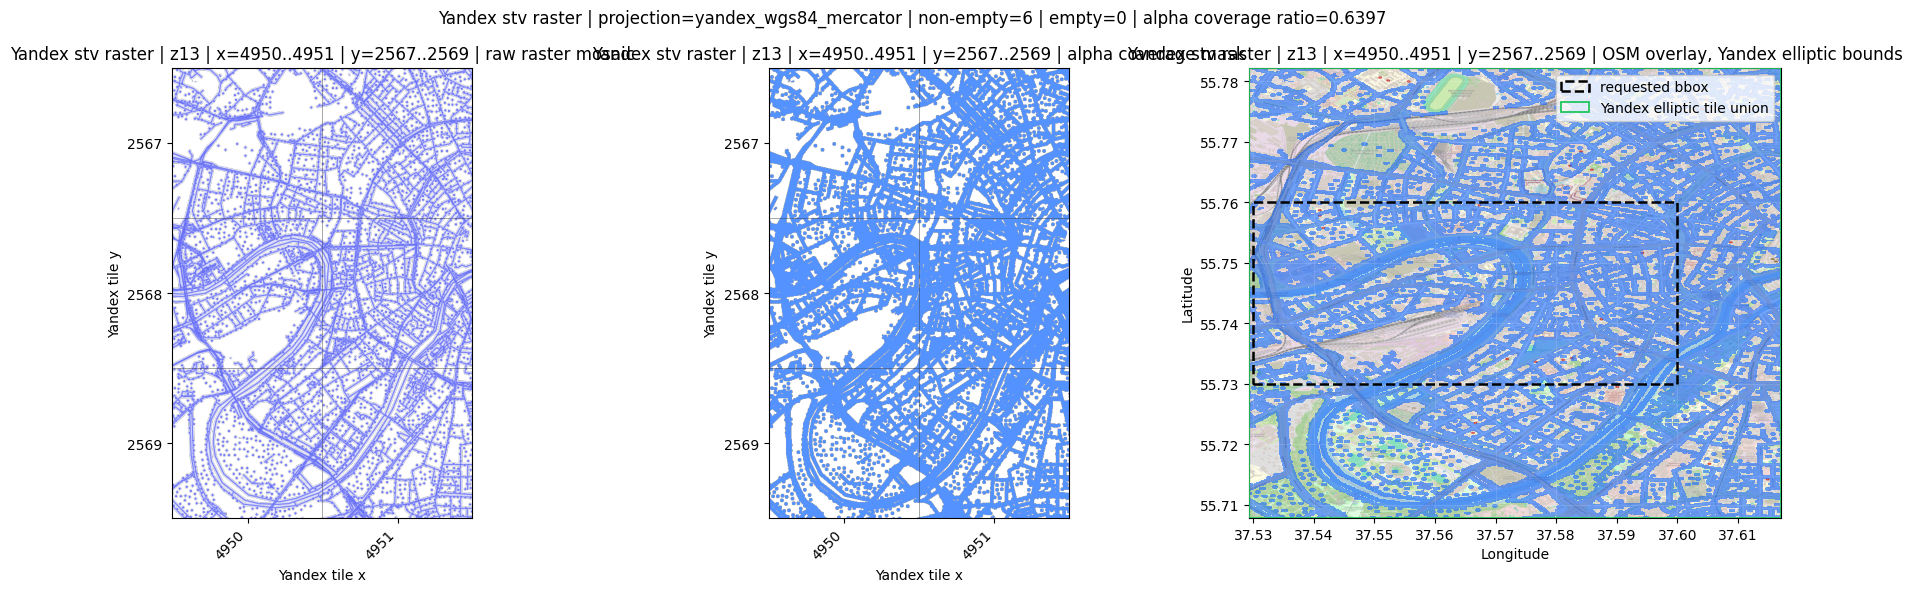

In [ ]:
def yandex_bounds_union(bounds_list: list[tuple[float, float, float, float]]) -> dict[str, float]:
    return {
        'min_lon': min(bounds[0] for bounds in bounds_list),
        'min_lat': min(bounds[1] for bounds in bounds_list),
        'max_lon': max(bounds[2] for bounds in bounds_list),
        'max_lat': max(bounds[3] for bounds in bounds_list),
    }


def yandex_lonlat_to_web_tile_fraction(lon: float, lat: float, zoom: int) -> tuple[float, float]:
    lat = max(min(lat, 85.05112878), -85.05112878)
    lat_rad = math.radians(lat)
    scale = 2 ** zoom
    x = (lon + 180.0) / 360.0 * scale
    y = (1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * scale
    return x, y


def yandex_fetch_basemap_image(
    bbox: dict[str, float],
    zoom: int,
    tile_template: str,
    timeout_seconds: int,
    headers: dict[str, str],
) -> tuple[np.ndarray, tuple[float, float, float, float], dict[str, int]]:
    x0f, y0f = yandex_lonlat_to_web_tile_fraction(bbox['min_lon'], bbox['max_lat'], zoom)
    x1f, y1f = yandex_lonlat_to_web_tile_fraction(bbox['max_lon'], bbox['min_lat'], zoom)

    x_min = math.floor(x0f)
    x_max = math.floor(x1f)
    y_min = math.floor(y0f)
    y_max = math.floor(y1f)

    mosaic = Image.new('RGB', ((x_max - x_min + 1) * 256, (y_max - y_min + 1) * 256))
    request_headers = {
        'User-Agent': headers.get('User-Agent', 'global-svi-coverage-observatory-notebook/0.2'),
        'Accept': 'image/avif,image/webp,image/apng,image/*,*/*;q=0.8',
        'Referer': 'https://www.openstreetmap.org/',
    }

    for tile_x in range(x_min, x_max + 1):
        for tile_y in range(y_min, y_max + 1):
            tile_url = tile_template.format(z=zoom, x=tile_x, y=tile_y)
            response = requests.get(tile_url, headers=request_headers, timeout=timeout_seconds)
            response.raise_for_status()
            tile_image = Image.open(io.BytesIO(response.content)).convert('RGB')
            mosaic.paste(tile_image, ((tile_x - x_min) * 256, (tile_y - y_min) * 256))

    crop_left = int(round((x0f - x_min) * 256))
    crop_right = int(round((x1f - x_min) * 256))
    crop_top = int(round((y0f - y_min) * 256))
    crop_bottom = int(round((y1f - y_min) * 256))
    cropped = mosaic.crop((crop_left, crop_top, crop_right, crop_bottom))

    return (
        np.asarray(cropped),
        (bbox['min_lon'], bbox['max_lon'], bbox['min_lat'], bbox['max_lat']),
        {'x_min': x_min, 'x_max': x_max, 'y_min': y_min, 'y_max': y_max, 'zoom': zoom},
    )


def yandex_raster_load_rgba_image(path: str) -> np.ndarray:
    with Image.open(path) as image:
        return np.array(image.convert('RGBA'))


def yandex_raster_mask_from_image(rgba: np.ndarray) -> np.ndarray:
    mask = np.zeros_like(rgba)
    alpha = rgba[:, :, 3] > 0
    mask[alpha] = np.array([25, 109, 255, 190], dtype=np.uint8)
    return mask


def build_yandex_raster_mosaic(tile_rows: list[dict]) -> tuple[np.ndarray, dict[str, int]]:
    if not tile_rows:
        raise ValueError('No Yandex raster tile rows available for mosaic assembly.')

    x_values = sorted({int(row['x']) for row in tile_rows})
    y_values = sorted({int(row['y']) for row in tile_rows})
    x_min, x_max = x_values[0], x_values[-1]
    y_min, y_max = y_values[0], y_values[-1]

    tile_width = 256
    tile_height = 256
    mosaic = np.zeros(((y_max - y_min + 1) * tile_height, (x_max - x_min + 1) * tile_width, 4), dtype=np.uint8)

    for row in tile_rows:
        output_path = row.get('output_path', '')
        if not output_path:
            continue
        rgba = yandex_raster_load_rgba_image(output_path)
        x = int(row['x'])
        y = int(row['y'])
        row_index = y - y_min
        col_index = x - x_min
        top = row_index * tile_height
        left = col_index * tile_width
        mosaic[top:top + tile_height, left:left + tile_width] = rgba

    info = {
        'x_min': x_min,
        'x_max': x_max,
        'y_min': y_min,
        'y_max': y_max,
        'tile_width': tile_width,
        'tile_height': tile_height,
    }
    return mosaic, info


def yandex_raster_rows_bounds(tile_rows: list[dict]) -> dict[str, float]:
    bounds = [
        yandex_tile_to_lonlat_bounds(int(row['x']), int(row['y']), int(row['source_zoom']))
        for row in tile_rows
    ]
    return yandex_bounds_union(bounds)


def plot_yandex_raster_result(result: dict, figsize: tuple[int, int] = (18, 6), show_tile_labels: bool = True) -> None:
    tile_rows = read_csv_rows(Path(result['tile_summary_path']))
    if not tile_rows:
        print('No Yandex raster tile rows found for visualization:', result['tile_summary_path'])
        return

    nonempty_rows = [row for row in tile_rows if str(row.get('is_empty', '')).lower() != 'true' and row.get('output_path')]
    raw_mosaic, info = build_yandex_raster_mosaic(tile_rows)
    mask_mosaic = yandex_raster_mask_from_image(raw_mosaic)
    bbox = result['manifest']['bbox']
    tile_union_bbox = yandex_raster_rows_bounds(tile_rows)

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    ax_raw, ax_mask, ax_map = axes
    ax_raw.imshow(raw_mosaic)
    ax_mask.imshow(mask_mosaic)

    if YANDEX_RASTER_BASEMAP_ENABLED:
        try:
            basemap_image, basemap_extent, basemap_tile_span = yandex_fetch_basemap_image(
                bbox=tile_union_bbox,
                zoom=YANDEX_RASTER_BASEMAP_ZOOM,
                tile_template=YANDEX_BASEMAP_TILE_TEMPLATE,
                timeout_seconds=YANDEX_BASEMAP_TIMEOUT_SECONDS,
                headers=YANDEX_RASTER_REQUEST_HEADERS,
            )
            ax_map.imshow(
                basemap_image,
                extent=basemap_extent,
                origin='upper',
                interpolation='bilinear',
                zorder=0,
            )
            print('Basemap tile span:', basemap_tile_span)
        except Exception as exc:
            print('Basemap fetch failed:', repr(exc))

    tile_union_extent = (
        tile_union_bbox['min_lon'],
        tile_union_bbox['max_lon'],
        tile_union_bbox['min_lat'],
        tile_union_bbox['max_lat'],
    )
    ax_map.imshow(mask_mosaic, extent=tile_union_extent, origin='upper', interpolation='nearest', alpha=0.82, zorder=1)

    title = (
        f"Yandex {result['manifest'].get('request_layer', 'stv')} raster | z{result['job']['source_zoom']} | "
        f"x={info['x_min']}..{info['x_max']} | y={info['y_min']}..{info['y_max']}"
    )
    ax_raw.set_title(title + ' | raw raster mosaic')
    ax_mask.set_title(title + ' | alpha coverage mask')
    ax_map.set_title(title + ' | OSM overlay, Yandex elliptic bounds')

    cols = info['x_max'] - info['x_min'] + 1
    rows = info['y_max'] - info['y_min'] + 1
    tile_width = info['tile_width']
    tile_height = info['tile_height']

    for ax in (ax_raw, ax_mask):
        for col in range(cols + 1):
            ax.axvline(col * tile_width - 0.5, color='#333333', linewidth=0.6, alpha=0.5)
        for row in range(rows + 1):
            ax.axhline(row * tile_height - 0.5, color='#333333', linewidth=0.6, alpha=0.5)
        if show_tile_labels:
            ax.set_xticks([(col + 0.5) * tile_width for col in range(cols)])
            ax.set_xticklabels([str(info['x_min'] + col) for col in range(cols)], rotation=45, ha='right')
            ax.set_yticks([(row + 0.5) * tile_height for row in range(rows)])
            ax.set_yticklabels([str(info['y_min'] + row) for row in range(rows)])
            ax.set_xlabel('Yandex tile x')
            ax.set_ylabel('Yandex tile y')
        else:
            ax.set_xticks([])
            ax.set_yticks([])

    ax_map.add_patch(
        Rectangle(
            (bbox['min_lon'], bbox['min_lat']),
            bbox['max_lon'] - bbox['min_lon'],
            bbox['max_lat'] - bbox['min_lat'],
            fill=False,
            edgecolor='black',
            linewidth=1.8,
            linestyle='--',
            label='requested bbox',
            zorder=3,
        )
    )
    ax_map.add_patch(
        Rectangle(
            (tile_union_bbox['min_lon'], tile_union_bbox['min_lat']),
            tile_union_bbox['max_lon'] - tile_union_bbox['min_lon'],
            tile_union_bbox['max_lat'] - tile_union_bbox['min_lat'],
            fill=False,
            edgecolor='#22c55e',
            linewidth=1.3,
            linestyle='-',
            label='Yandex elliptic tile union',
            zorder=3,
        )
    )
    ax_map.set_xlim(tile_union_bbox['min_lon'], tile_union_bbox['max_lon'])
    ax_map.set_ylim(tile_union_bbox['min_lat'], tile_union_bbox['max_lat'])
    ax_map.set_xlabel('Longitude')
    ax_map.set_ylabel('Latitude')
    ax_map.legend(loc='best')
    ax_map.grid(alpha=0.12, color='white')

    total_coverage_pixels = sum(int(row['coverage_pixel_count']) for row in nonempty_rows if row.get('coverage_pixel_count'))
    total_pixels = sum(int(row['total_pixel_count']) for row in nonempty_rows if row.get('total_pixel_count'))
    coverage_ratio = total_coverage_pixels / total_pixels if total_pixels else 0.0
    fig.suptitle(
        f"Yandex stv raster | projection={YANDEX_RASTER_TILE_GRID_PROJECTION} | "
        f"non-empty={result['manifest']['nonempty_tile_count']} | "
        f"empty={result['manifest']['empty_tile_count']} | alpha coverage ratio={coverage_ratio:.4f}"
    )
    plt.tight_layout()
    plt.show()


for result in yandex_raster_results:
    plot_yandex_raster_result(result)
